# Analisis Tokopedia

Notebook ini menganalisis performa bisnis Tokopedia berdasarkan data pengguna, transaksi, dan pengiriman. Fokus analisis adalah memahami pertumbuhan transaksi, efektivitas promo, tingkat retensi pengguna, dan keterlambatan pengiriman untuk mendukung keputusan bisnis yang lebih profitabel dan berkelanjutan.

**Goal utama:** menghasilkan insight yang dapat membantu Tokopedia mengoptimalkan budget promo, meningkatkan SLA logistik, dan memperbaiki retensi pengguna berdasarkan data yang valid dan bersih.

**Proses:** analisis dimulai dari data understanding dan pembersihan data, dilanjutkan dengan penggabungan tabel, eksplorasi bisnis, pengujian statistik, dan diakhiri dengan kesimpulan serta rekomendasi.

## Pernyataan Masalah

Tokopedia mengalami pertumbuhan e-commerce yang sangat cepat, tetapi di balik pertumbuhan transaksi dan GMV, perusahaan menghadapi tantangan dalam menjaga profitabilitas dan retensi pengguna. Promo besar-besaran seperti WIB, cashback, dan subsidi ongkir membantu akuisisi, namun belum tentu meningkatkan repeat order secara berkelanjutan. Keterlambatan pengiriman dan anomali data dari sistem legacy juga memperburuk pengalaman pengguna dan menghambat pengambilan keputusan.

**Tujuan section:** menerjemahkan kebutuhan bisnis menjadi pertanyaan analisis yang dapat dijawab dengan data dan menghubungkannya dengan masalah profitabilitas, retensi, dan logistik.

**Proses:** kebutuhan stakeholder diubah menjadi pertanyaan terukur tentang tren transaksi, profil pengguna, metode pembayaran, promosi, retensi cohort, serta performa kurir.

Pertanyaan bisnis yang dijawab:
1. Seberapa besar dampak promo dan retensi terhadap profitabilitas jangka panjang?
2. Segmen user mana yang cenderung menjadi promo-hunter dan berisiko churn?
3. Bagaimana tren order, GMV, net revenue, dan promo dari waktu ke waktu?
4. Metode pembayaran apa yang paling dominan dan apakah ada anomali transaksi?
5. Kota atau kelompok umur mana yang berkontribusi paling besar terhadap transaksi?
6. Seberapa besar keterlambatan pengiriman memengaruhi repeat order dan pengalaman pengguna?
7. Apakah terdapat hubungan antara metode pembayaran dan lokasi pengguna, serta antara lokasi dan durasi pengiriman?
8. Apakah ada anomali data sistem seperti tanggal transaksi mendahului tanggal registrasi atau transaksi yang tidak valid secara bisnis?

## Import Library dan Konfigurasi

**Tujuan section:** menyiapkan library untuk manipulasi data, visualisasi, dan pengujian statistik serta menetapkan konfigurasi tampilan notebook agar output konsisten.

**Proses:** mengimpor pandas dan numpy untuk pengolahan data, matplotlib dan seaborn untuk grafik, serta scipy untuk Mann-Whitney dan chi-square.

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, chi2_contingency

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='deep')

## Memuat Data

**Tujuan section:** membaca tiga sumber data ke dalam DataFrame terpisah agar setiap tabel dapat diperiksa sebelum digabungkan.

**Proses:** file CSV dibaca menggunakan pandas, kemudian beberapa baris awal ditampilkan untuk memeriksa nama kolom, contoh nilai, dan kesesuaian struktur dengan kebutuhan analisis.

In [4]:
cohort = pd.read_csv('tokopedia_users.csv')
transactions = pd.read_csv('tokopedia_transactions.csv')
deliveries = pd.read_csv('tokopedia_deliveries.csv')

users_raw = users.copy()
transactions_raw = transactions.copy()
deliveries_raw = deliveries.copy()

display(users.head(), transactions.head(), deliveries.head())

,user_id,join_date,gender,location,age
0,USR00001,2022-04-13,Female,Yogyakarta,21
1,USR00002,2023-03-12,Female,Bandung,33
2,USR00003,2022-09-28,Female,Bandung,20
3,USR00004,2022-04-17,Female,Bandung,25
4,USR00005,2022-03-13,Female,Bandung,56


,order_id,user_id,order_date,payment_method,promo_amount,total_amount
0,ORD000001,USR01057,2023-09-26,GoPay,0,531947
1,ORD000002,USR26336,2022-08-10,ovo,10000,1054104
2,ORD000003,USR25466,2024-05-21,COD,0,1067647
3,ORD000004,USR42303,2024-06-18,ovo,10000,175629
4,ORD000005,USR29370,2024-03-11,ovo,0,1438378


,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26
3,ORD000004,GoTo Logistics,2024-06-18,2024-06-23
4,ORD000005,SiCepat,2024-03-13,2024-03-14


## Penjelasan Kolom Dataset

**Tujuan section:** mendokumentasikan arti setiap kolom agar proses cleaning, penggabungan tabel, feature engineering, dan interpretasi hasil analisis dapat dipahami dengan jelas.

### Dataset `users`

| Kolom | Penjelasan | Peran dalam analisis |
|---|---|---|
| `user_id` | ID unik pengguna | Key untuk menghubungkan users dengan transactions |
| `join_date` | Tanggal pengguna bergabung | Dasar cohort retention dan fitur `join_month` |
| `gender` | Gender pengguna | Profil pengguna; missing diubah menjadi `Unknown` |
| `location` | Kota atau lokasi pengguna | Segmentasi lokasi dan uji chi-square |
| `age` | Umur pengguna dalam tahun | Segmentasi `age_group` dan analisis profil pengguna |

### Dataset `transactions`

| Kolom | Penjelasan | Peran dalam analisis |
|---|---|---|
| `order_id` | ID unik order | Key untuk menghubungkan transaksi dengan deliveries |
| `user_id` | ID pengguna yang melakukan order | Key untuk menghubungkan transaksi dengan users |
| `order_date` | Tanggal order dibuat | Tren transaksi dan fitur periode bulanan |
| `payment_method` | Metode pembayaran yang digunakan | Standardisasi kategori, agregasi GMV, dan uji chi-square |
| `promo_amount` | Nilai promo atau potongan harga | Menghitung total promo, promo rate, dan net amount |
| `total_amount` | Nilai bruto transaksi sebelum promo | Menghitung GMV dan average order value; nominal negatif dan outlier ditangani saat cleaning |

### Dataset `deliveries`

| Kolom | Penjelasan | Peran dalam analisis |
|---|---|---|
| `order_id` | ID order yang dikirim | Key untuk menghubungkan delivery dengan transactions |
| `courier_name` | Nama mitra kurir | Perbandingan performa kurir; missing tidak diimputasi |
| `dispatch_date` | Tanggal order dikirim oleh penjual atau gudang | Titik awal perhitungan durasi pengiriman |
| `delivery_date` | Tanggal order diterima atau selesai dikirim | Titik akhir perhitungan `delivery_days` |

### Relasi Key

- `users.user_id` berelasi dengan `transactions.user_id`.
- `transactions.order_id` berelasi dengan `deliveries.order_id`.
- `transactions` menjadi tabel utama karena sebagian besar metrik dihitung pada level order.

## Data Understanding dan Data Quality

**Tujuan section:** memahami struktur, tipe data, ukuran, missing value, kategori unik, dan duplikat sebelum melakukan perubahan pada data. Pemeriksaan ini menjadi dasar pemilihan metode cleaning.

**Proses:** setiap tabel diringkas melalui shape, statistik deskriptif, tipe data, jumlah nilai kosong, jumlah kategori unik, dan pemeriksaan duplikat pada key.

In [3]:
for name, data in {'users': users, 'transactions': transactions, 'deliveries': deliveries}.items():
    print(f'{name}: {data.shape}')
    display(data.describe(include='all').T)

users: (50000, 5)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,50000,50000,USR00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
join_date,50000,730,2023-10-19,93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,45106,2,Female,22693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,50000,6,Surabaya,8444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,50000.0,NaN,NaN,NaN,39.59922,14.430234,15.0,27.0,40.0,52.0,64.0


transactions: (300000, 6)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,300000,300000,ORD000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,300000,49883,USR03807,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,300000,1186,2023-06-23,471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,300000,9,gopay,33672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_amount,300000.0,NaN,NaN,NaN,7473.6,12170.885895,0.0,0.0,0.0,10000.0,50000.0
total_amount,300000.0,NaN,NaN,NaN,10896439.239267,98873527.866465,-150000.0,526199.75,1025482.0,1523252.0,999999999.0


deliveries: (300000, 4)


,count,unique,top,freq
order_id,300000,300000,ORD000001,1
courier_name,284915,4,GoTo Logistics,120082
dispatch_date,300000,1188,2023-10-02,466
delivery_date,300000,1188,2023-08-01,474


In [4]:
def quality_report(data):
    return pd.DataFrame({
        'dtype': data.dtypes.astype(str),
        'missing': data.isna().sum(),
        'missing_pct': (data.isna().mean() * 100).round(2),
        'unique': data.nunique(),
        'duplicates': data.duplicated().sum()
    })

display(quality_report(users))
display(quality_report(transactions))
display(quality_report(deliveries))
print('Duplicate user_id:', users['user_id'].duplicated().sum())
print('Duplicate order_id transactions:', transactions['order_id'].duplicated().sum())
print('Duplicate order_id deliveries:', deliveries['order_id'].duplicated().sum())

,dtype,missing,missing_pct,unique,duplicates
user_id,str,0,0.00,50000,0
join_date,str,0,0.00,730,0
gender,str,4894,9.79,2,0
location,str,0,0.00,6,0
age,int64,0,0.00,50,0


,dtype,missing,missing_pct,unique,duplicates
order_id,str,0,0.0,300000,0
user_id,str,0,0.0,49883,0
order_date,str,0,0.0,1186,0
payment_method,str,0,0.0,9,0
promo_amount,int64,0,0.0,4,0
total_amount,int64,0,0.0,272889,0


,dtype,missing,missing_pct,unique,duplicates
order_id,str,0,0.00,300000,0
courier_name,str,15085,5.03,4,0
dispatch_date,str,0,0.00,1188,0
delivery_date,str,0,0.00,1188,0


Duplicate user_id: 0
Duplicate order_id transactions: 0
Duplicate order_id deliveries: 0


## Data Cleaning dan Perbaikan Data per Tipe

**Tujuan section:** memperbaiki anomali yang dapat mengganggu validitas analisis, dengan alasan dan jumlah baris terdampak yang terdokumentasi pada setiap tipe cleaning.

**Proses:** pembersihan dipisahkan menjadi data duplikat, data formatting, nilai invalid dan outlier, serta missing values. Audit before/after dilakukan setelah seluruh tipe pembersihan selesai.

### Data Duplikat

**Tujuan:** menjaga keunikan record berdasarkan key utama agar proses merge tidak menggandakan transaksi.

**Proses:** `user_id` dideduplikasi pada tabel users, sedangkan `order_id` dideduplikasi pada tabel transactions dan deliveries. Jumlah baris sebelum dan sesudah dibandingkan melalui `key_cleaning_report`.

In [5]:
before_rows = {
    'users': len(users),
    'transactions': len(transactions),
    'deliveries': len(deliveries)
}

users = users.drop_duplicates('user_id').copy()
transactions = transactions.drop_duplicates('order_id').copy()
deliveries = deliveries.drop_duplicates('order_id').copy()

after_rows = {
    'users': len(users),
    'transactions': len(transactions),
    'deliveries': len(deliveries)
}
key_cleaning_report = pd.DataFrame({
    'table': list(before_rows),
    'rows_before': list(before_rows.values()),
    'rows_after': list(after_rows.values())
})
key_cleaning_report['rows_removed'] = key_cleaning_report['rows_before'] - key_cleaning_report['rows_after']
print('Tahap 1 - deduplikasi key')
display(key_cleaning_report)

Tahap 1 - deduplikasi key


,table,rows_before,rows_after,rows_removed
0,users,50000,50000,0
1,transactions,300000,300000,0
2,deliveries,300000,300000,0


### Data Formatting: Tanggal

**Tujuan:** memastikan seluruh kolom tanggal dapat digunakan untuk analisis waktu dan perhitungan durasi.

**Proses:** setiap kolom tanggal dikonversi menggunakan `pd.to_datetime(..., errors='coerce')`, lalu jumlah nilai yang berubah menjadi `NaT` dibandingkan sebelum dan sesudah konversi.

In [6]:
date_columns = {
    'users': ['join_date'],
    'transactions': ['order_date'],
    'deliveries': ['dispatch_date', 'delivery_date']
}

invalid_date_report = []
for table_name, columns in date_columns.items():
    data = {'users': users, 'transactions': transactions, 'deliveries': deliveries}[table_name]
    for column in columns:
        before_invalid = data[column].isna().sum()
        data[column] = pd.to_datetime(data[column], errors='coerce')
        after_invalid = data[column].isna().sum()
        invalid_date_report.append({
            'table': table_name,
            'column': column,
            'invalid_before': before_invalid,
            'invalid_after': after_invalid,
            'new_invalid_values': after_invalid - before_invalid
        })

print('Tahap 2 - konversi tanggal')
display(pd.DataFrame(invalid_date_report))

Tahap 2 - konversi tanggal


,table,column,invalid_before,invalid_after,new_invalid_values
0,users,join_date,0,0,0
1,transactions,order_date,0,0,0
2,deliveries,dispatch_date,0,0,0
3,deliveries,delivery_date,0,0,0


### Nilai Invalid dan Outlier: Nominal Transaksi

**Tujuan:** memastikan nilai transaksi dan promo memenuhi aturan bisnis dasar.

**Proses:** dibuat boolean mask untuk mencari baris dengan `total_amount < 0` atau `promo_amount < 0`; baris tersebut dihitung dan dikeluarkan. Outlier nominal ditangani pada subsection terpisah menggunakan aturan IQR.

`total_amount` dan `promo_amount` tidak boleh bernilai negatif karena tidak dapat mewakili transaksi atau potongan harga yang valid.

In [7]:
transactions_before_amount_filter = len(transactions)
invalid_amount_mask = (transactions['total_amount'] < 0) | (transactions['promo_amount'] < 0)
invalid_amount_rows = int(invalid_amount_mask.sum())
transactions = transactions.loc[~invalid_amount_mask].copy()

print('Tahap 3 - validasi nilai transaksi')
print(f'Baris sebelum: {transactions_before_amount_filter:,}')
print(f'Baris tidak valid yang dikeluarkan: {invalid_amount_rows:,}')
print(f'Baris sesudah: {len(transactions):,}')
display(transactions.loc[(transactions['total_amount'] < 0) | (transactions['promo_amount'] < 0)])

Tahap 3 - validasi nilai transaksi
Baris sebelum: 300,000
Baris tidak valid yang dikeluarkan: 3,032
Baris sesudah: 296,968


,order_id,user_id,order_date,payment_method,promo_amount,total_amount


### Data Formatting: Metode Pembayaran

**Tujuan:** menyatukan label yang merujuk pada kanal pembayaran yang sama agar agregasi tidak terpecah.

**Proses:** teks dibersihkan dari spasi berlebih dan diubah menjadi huruf kecil, kemudian alias GoPay dan virtual account dipetakan menggunakan dictionary mapping. Distribusi sebelum dan sesudah dibandingkan.

In [8]:
payment_before = transactions['payment_method'].value_counts(dropna=False).rename('rows_before')
transactions['payment_method'] = transactions['payment_method'].astype('string').str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
payment_map = {
    'gopay': 'go_pay', 'go-pay': 'go_pay', 'go pay': 'go_pay',
    'ovo': 'ovo', 'cod': 'cod',
    'bca va': 'bank_transfer', 'bca virtual account': 'bank_transfer',
    'mandiri va': 'bank_transfer', 'bank transfer': 'bank_transfer'
}
transactions['payment_method'] = transactions['payment_method'].replace(payment_map).fillna('unknown')
payment_after = transactions['payment_method'].value_counts(dropna=False).rename('rows_after')
payment_audit = pd.concat([payment_before, payment_after], axis=1).fillna(0).astype(int)

print('Tahap 4 - standardisasi metode pembayaran')
display(payment_audit.sort_index())

Tahap 4 - standardisasi metode pembayaran


,rows_before,rows_after
payment_method,,
BCA Virtual Account,32989,0
COD,32942,0
GO-PAY,32937,0
GoPay,32915,0
Mandiri VA,32994,0
OVO,32843,0
bank_transfer,0,99189
bca va,33206,0
cod,0,32942


### Audit Sementara Setelah Duplikat dan Formatting

**Tujuan:** memeriksa kondisi data setelah deduplikasi, konversi tanggal, validasi nominal, dan standardisasi pembayaran sebelum menangani missing values serta outlier.

**Proses:** jumlah baris, missing value, tipe data, kategori, dan duplikat diperiksa pada ketiga tabel. Audit final dilakukan pada section perbandingan before/after setelah seluruh tipe cleaning selesai.

Missing value yang belum ditangani tetap dilaporkan secara transparan; khusus `courier_name`, order tetap dipertahankan tetapi tidak digunakan dalam agregasi kurir.

In [9]:
cleaning_audit = pd.DataFrame({
    'table': ['users', 'transactions', 'deliveries'],
    'rows_after_cleaning': [len(users), len(transactions), len(deliveries)],
    'missing_values': [int(users.isna().sum().sum()), int(transactions.isna().sum().sum()), int(deliveries.isna().sum().sum())]
})
print('Audit akhir cleaning')
display(cleaning_audit)
display(quality_report(users), quality_report(transactions), quality_report(deliveries))

Audit akhir cleaning


,table,rows_after_cleaning,missing_values
0,users,50000,4894
1,transactions,296968,0
2,deliveries,300000,15085


,dtype,missing,missing_pct,unique,duplicates
user_id,str,0,0.00,50000,0
join_date,datetime64[us],0,0.00,730,0
gender,str,4894,9.79,2,0
location,str,0,0.00,6,0
age,int64,0,0.00,50,0


,dtype,missing,missing_pct,unique,duplicates
order_id,str,0,0.0,296968,0
user_id,str,0,0.0,49875,0
order_date,datetime64[us],0,0.0,1186,0
payment_method,string,0,0.0,4,0
promo_amount,int64,0,0.0,4,0
total_amount,int64,0,0.0,272888,0


,dtype,missing,missing_pct,unique,duplicates
order_id,str,0,0.00,300000,0
courier_name,str,15085,5.03,4,0
dispatch_date,datetime64[us],0,0.00,1188,0
delivery_date,datetime64[us],0,0.00,1188,0


### Missing Values

**Tujuan:** menangani nilai kosong tanpa membuat asumsi yang tidak dapat dibuktikan.

**Proses:** missing `gender` diubah menjadi kategori `Unknown`, sedangkan missing `courier_name` dipertahankan dan dikeluarkan dari agregasi kurir. Jumlah missing sebelum dan sesudah dicatat dalam laporan.

In [10]:
missing_before = {
    'users.gender': int(users['gender'].isna().sum()),
    'deliveries.courier_name': int(deliveries['courier_name'].isna().sum())
}
users['gender'] = users['gender'].fillna('Unknown')

missing_after = {
    'users.gender': int(users['gender'].isna().sum()),
    'deliveries.courier_name': int(deliveries['courier_name'].isna().sum())
}
missing_report = pd.DataFrame({
    'column': list(missing_before),
    'missing_before': list(missing_before.values()),
    'missing_after': list(missing_after.values()),
    'action': [
        'Isi dengan kategori Unknown',
        'Pertahankan missing; dikeluarkan dari analisis kurir'
    ]
})
print('Missing values')
display(missing_report)

Missing values


,column,missing_before,missing_after,action
0,users.gender,4894,0,Isi dengan kategori Unknown
1,deliveries.courier_name,15085,15085,Pertahankan missing; dikeluarkan dari analisis...


### Outlier: Nominal Transaksi

**Tujuan:** mengurangi pengaruh nilai transaksi ekstrem terhadap GMV dan rata-rata nilai order.

**Proses:** kuartil pertama dan ketiga dihitung, IQR ditentukan, lalu transaksi di atas batas `Q3 + 1.5 * IQR` dikeluarkan. Jumlah outlier dan batas atas ditampilkan untuk audit.

In [11]:
q1 = transactions['total_amount'].quantile(0.25)
q3 = transactions['total_amount'].quantile(0.75)
iqr = q3 - q1
upper_amount_limit = q3 + 1.5 * iqr
amount_outlier_mask = transactions['total_amount'] > upper_amount_limit
amount_outlier_count = int(amount_outlier_mask.sum())
transactions = transactions.loc[~amount_outlier_mask].copy()

print('Outlier nominal transaksi')
print(f'Batas atas total_amount menurut IQR: Rp{upper_amount_limit:,.0f}')
print(f'Outlier total_amount yang dikeluarkan: {amount_outlier_count:,}')

Outlier nominal transaksi
Batas atas total_amount menurut IQR: Rp3,007,968
Outlier total_amount yang dikeluarkan: 2,968


## Perbandingan Data Sebelum dan Sesudah Cleaning

**Tujuan section:** memperlihatkan dampak pembersihan data secara langsung, bukan hanya menjelaskan aturan cleaning.

**Proses:** snapshot data mentah yang dibuat saat load dibandingkan dengan DataFrame setelah seluruh tahap cleaning. Perbandingan meliputi jumlah baris, total missing value, dan contoh baris teratas.

In [12]:
before_after_report = pd.DataFrame({
    'table': ['users', 'transactions', 'deliveries'],
    'rows_before_cleaning': [len(users_raw), len(transactions_raw), len(deliveries_raw)],
    'rows_after_cleaning': [len(users), len(transactions), len(deliveries)],
    'rows_removed': [len(users_raw) - len(users), len(transactions_raw) - len(transactions), len(deliveries_raw) - len(deliveries)],
    'missing_before': [int(users_raw.isna().sum().sum()), int(transactions_raw.isna().sum().sum()), int(deliveries_raw.isna().sum().sum())],
    'missing_after': [int(users.isna().sum().sum()), int(transactions.isna().sum().sum()), int(deliveries.isna().sum().sum())]
})
print('Ringkasan perubahan data')
display(before_after_report)

print('Contoh users sebelum cleaning')
display(users_raw.head(3))
print('Contoh users sesudah cleaning')
display(users.head(3))

print('Contoh transactions sebelum cleaning')
display(transactions_raw.head(3))
print('Contoh transactions sesudah cleaning')
display(transactions.head(3))

print('Contoh deliveries sebelum cleaning')
display(deliveries_raw.head(3))
print('Contoh deliveries sesudah cleaning')
display(deliveries.head(3))

Ringkasan perubahan data


,table,rows_before_cleaning,rows_after_cleaning,rows_removed,missing_before,missing_after
0,users,50000,50000,0,4894,0
1,transactions,300000,294000,6000,0,0
2,deliveries,300000,300000,0,15085,15085


Contoh users sebelum cleaning


,user_id,join_date,gender,location,age
0,USR00001,2022-04-13,Female,Yogyakarta,21
1,USR00002,2023-03-12,Female,Bandung,33
2,USR00003,2022-09-28,Female,Bandung,20


Contoh users sesudah cleaning


...

,order_id,user_id,order_date,payment_method,promo_amount,total_amount
0,ORD000001,USR01057,2023-09-26,go_pay,0,531947
1,ORD000002,USR26336,2022-08-10,ovo,10000,1054104
2,ORD000003,USR25466,2024-05-21,cod,0,1067647


Contoh deliveries sebelum cleaning


,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26


Contoh deliveries sesudah cleaning


,order_id,courier_name,dispatch_date,delivery_date
0,ORD000001,GoTo Logistics,2023-09-26,2023-09-30
1,ORD000002,SiCepat,2022-08-12,2022-08-16
2,ORD000003,JNE,2024-05-23,2024-05-26


## Penggabungan Data dan Feature Engineering

**Tujuan section:** menghubungkan pengguna, transaksi, dan pengiriman pada level order, lalu membentuk variabel turunan yang dibutuhkan untuk analisis waktu, promo, umur, cohort, dan durasi pengiriman.

**Proses:** transactions digabungkan ke users melalui `user_id` dan ke deliveries melalui `order_id` dengan validasi relasi; setelah itu dibuat fitur bulan transaksi, bulan bergabung, durasi delivery, promo rate, net amount, dan age group.

In [13]:
orders = (transactions.merge(users, on='user_id', how='left', validate='many_to_one')
                  .merge(deliveries, on='order_id', how='left', validate='one_to_one'))

orders['delivery_days'] = (orders['delivery_date'] - orders['dispatch_date']).dt.days
orders.loc[orders['delivery_days'] < 0, 'delivery_days'] = np.nan
orders['transaction_month'] = orders['order_date'].dt.to_period('M').astype('string')
orders['join_month'] = orders['join_date'].dt.to_period('M').astype('string')
orders['order_month'] = orders['order_date'].dt.to_period('M').astype('string')
orders['promo_rate'] = np.where(orders['total_amount'] > 0, orders['promo_amount'] / orders['total_amount'], 0)
orders['net_amount'] = orders['total_amount'] - orders['promo_amount']
orders['age_group'] = pd.cut(orders['age'], bins=[0, 20, 30, 40, 50, 120], labels=['<=20', '21-30', '31-40', '41-50', '>50'])

print('Ukuran data gabungan:', orders.shape)
print('Transaksi tanpa user:', transactions.loc[~transactions['user_id'].isin(users['user_id'])].shape[0])
print('Transaksi tanpa delivery:', transactions.loc[~transactions['order_id'].isin(deliveries['order_id'])].shape[0])
print('Durasi delivery negatif yang ditandai missing:', orders['delivery_days'].isna().sum())
display(orders.head())

Ukuran data gabungan: (294000, 20)
Transaksi tanpa user: 0
Transaksi tanpa delivery: 0
Durasi delivery negatif yang ditandai missing: 8829


,order_id,user_id,order_date,payment_method,promo_amount,total_amount,join_date,gender,location,age,courier_name,dispatch_date,delivery_date,delivery_days,transaction_month,join_month,order_month,promo_rate,net_amount,age_group
0,ORD000001,USR01057,2023-09-26,go_pay,0,531947,2023-07-08,Female,Jakarta,20,GoTo Logistics,2023-09-26,2023-09-30,4.0,2023-09,2023-07,2023-09,0.000000,531947,<=20
1,ORD000002,USR26336,2022-08-10,ovo,10000,1054104,2022-01-03,Male,Medan,23,SiCepat,2022-08-12,2022-08-16,4.0,2022-08,2022-01,2022-08,0.009487,1044104,21-30
2,ORD000003,USR25466,2024-05-21,cod,0,1067647,2023-07-01,Male,Jakarta,46,JNE,2024-05-23,2024-05-26,3.0,2024-05,2023-07,2024-05,0.000000,1067647,41-50
3,ORD000004,USR42303,2024-06-18,ovo,10000,175629,2023-06-23,Female,Yogyakarta,35,GoTo Logistics,2024-06-18,2024-06-23,5.0,2024-06,2023-06,2024-06,0.056938,165629,31-40
4,ORD000005,USR29370,2024-03-11,ovo,0,1438378,2023-07-31,Female,Yogyakarta,39,SiCepat,2024-03-13,2024-03-14,1.0,2024-03,2023-07,2024-03,0.000000,1438378,31-40


## Data Quality Check Setelah Merge

**Tujuan section:** memastikan integritas data setelah penggabungan tiga tabel dengan memeriksa missing values, duplicates, anomali logis (tanggal tidak konsisten), dan outliers pada data gabungan.

**Proses:** quality check dilakukan pada tiga level: structural quality (missing, duplicates), logical quality (anomali data bisnis), dan value quality (outliers). Hasil pengecekan akan digunakan untuk menentukan action yang tepat.

**Catatan Penting:** Nilai ~17-22% untuk month_since_join = 0 di cohort adalah BENAR (bukan error), artinya hanya 17-22% pengguna yang melakukan transaksi di bulan bergabung.

In [ ]:
# ===== DATA QUALITY CHECK SETELAH MERGE =====
print('=' * 80)
print('DATA QUALITY CHECK SETELAH MERGE')
print('=' * 80)

# 1. STRUCTURAL QUALITY
print('\n1. STRUCTURAL QUALITY')
print('-' * 80)

missing_summary = pd.DataFrame({
    'Column': orders.columns,
    'Missing_Count': orders.isna().sum(),
    'Missing_Pct': (orders.isna().mean() * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print('\nMissing Values:')
display(missing_summary[missing_summary['Missing_Count'] > 0])

print(f'\nDuplicate order_id: {orders["order_id"].duplicated().sum()}')
print(f'Duplicate user_id: {orders["user_id"].duplicated().sum()}')

# 2. LOGICAL QUALITY
print('\n2. LOGICAL QUALITY - ANOMALI DATA BISNIS')
print('-' * 80)

order_before_join = (orders['order_date'] < orders['join_date']).sum()
delivery_before_dispatch = (orders['delivery_date'] < orders['dispatch_date']).sum()
invalid_promo = (orders['promo_amount'] > orders['total_amount']).sum()
negative_net = (orders['net_amount'] < 0).sum()

print(f'\nOrder date SEBELUM join date: {order_before_join} ({order_before_join/len(orders)*100:.2f}%)')
print(f'Delivery date SEBELUM dispatch date: {delivery_before_dispatch} ({delivery_before_dispatch/len(orders)*100:.2f}%)')
print(f'Promo amount > total amount: {invalid_promo} ({invalid_promo/len(orders)*100:.2f}%)')
print(f'Net amount negatif: {negative_net} ({negative_net/len(orders)*100:.2f}%)')

quality_issues = pd.DataFrame({
    'Issue': ['Order < join date', 'Delivery < dispatch', 'Promo > Total', 'Net Amount < 0'],
    'Count': [order_before_join, delivery_before_dispatch, invalid_promo, negative_net],
    'Percentage': [f'{order_before_join/len(orders)*100:.2f}%', 
                   f'{delivery_before_dispatch/len(orders)*100:.2f}%',
                   f'{invalid_promo/len(orders)*100:.2f}%',
                   f'{negative_net/len(orders)*100:.2f}%']
})

print('\n✓ Ringkasan Quality Issues:')
display(quality_issues)

In [ ]:
# ===== ACTION PLAN =====
print('\n' + '=' * 80)
print('ACTION PLAN - RESPONS TERHADAP DATA QUALITY ISSUES')
print('=' * 80)

print('\n[ACTION 1] Delivery date SEBELUM dispatch date')
print('-' * 80)
print(f'Issue: {delivery_before_dispatch} records')
print('Status: REMOVE - Logika tidak mungkin (paket tidak bisa diterima sebelum dikirim)')
if delivery_before_dispatch > 0:
    before = len(orders)
    orders = orders[~(orders['delivery_date'] < orders['dispatch_date'])].copy()
    removed = before - len(orders)
    print(f'✅ Removed: {removed} records')
    print(f'   Remaining: {len(orders):,} records')

print('\n[ACTION 2] Promo amount > total amount')
print('-' * 80)
print(f'Issue: {invalid_promo} records')
print('Status: REMOVE - Logika invalid (potongan tidak bisa lebih besar dari nilai transaksi)')
if invalid_promo > 0:
    before = len(orders)
    orders = orders[~(orders['promo_amount'] > orders['total_amount'])].copy()
    removed = before - len(orders)
    print(f'✅ Removed: {removed} records')
    print(f'   Remaining: {len(orders):,} records')

print('\n[ACTION 3] Order date SEBELUM join date')
print('-' * 80)
print(f'Issue: {order_before_join} records')
print('Status: FLAG BUT RETAIN - Kemungkinan data entry error atau transaksi legacy')
if order_before_join > 0:
    orders['anomaly_order_before_join'] = orders['order_date'] < orders['join_date']
    print(f'✅ Flagged {order_before_join} records untuk investigasi terpisah')
else:
    orders['anomaly_order_before_join'] = False

print('\n' + '=' * 80)
print(f'FINAL DATA SIZE: {len(orders):,} records (from 294,000 initial)')
print('=' * 80)

## Data Quality Check Setelah Merge

**Tujuan section:** memastikan integritas data setelah penggabungan tiga tabel dengan memeriksa missing values, duplicates, anomali logis (tanggal tidak konsisten), dan outliers pada data gabungan.

**Proses:** quality check dilakukan pada tiga level: structural quality (missing, duplicates), logical quality (anomali data bisnis), dan value quality (outliers). Hasil pengecekan akan digunakan untuk menentukan action yang tepat.

In [ ]:
# ===== DATA QUALITY CHECK SETELAH MERGE =====
print('=' * 80)
print('DATA QUALITY CHECK SETELAH MERGE')
print('=' * 80)

# 1. STRUCTURAL QUALITY
print('\n1. STRUCTURAL QUALITY')
print('-' * 80)
missing_summary = pd.DataFrame({
    'column': orders.columns,
    'missing_count': orders.isna().sum(),
    'missing_pct': (orders.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
print('\nMissing Values:')
display(missing_summary[missing_summary['missing_count'] > 0])

print(f'\nDuplicate order_id: {orders["order_id"].duplicated().sum()}')
print(f'Duplicate user_id: {orders["user_id"].duplicated().sum()}')

# 2. LOGICAL QUALITY
print('\n2. LOGICAL QUALITY - ANOMALI DATA BISNIS')
print('-' * 80)
order_before_join = (orders['order_date'] < orders['join_date']).sum()
delivery_before_dispatch = (orders['delivery_date'] < orders['dispatch_date']).sum()
invalid_promo = (orders['promo_amount'] > orders['total_amount']).sum()
negative_net = (orders['net_amount'] < 0).sum()

print(f'Order date SEBELUM join date: {order_before_join} records ({order_before_join/len(orders)*100:.2f}%)')
print(f'Delivery date SEBELUM dispatch date: {delivery_before_dispatch} records ({delivery_before_dispatch/len(orders)*100:.2f}%)')
print(f'Promo amount > total amount: {invalid_promo} records ({invalid_promo/len(orders)*100:.2f}%)')
print(f'Net amount negatif: {negative_net} records ({negative_net/len(orders)*100:.2f}%)')

quality_issues = pd.DataFrame({
    'Issue': ['Order < join date', 'Delivery < dispatch date', 'Promo > Total', 'Net Amount < 0'],
    'Count': [order_before_join, delivery_before_dispatch, invalid_promo, negative_net],
    'Percentage': [f'{order_before_join/len(orders)*100:.2f}%', 
                   f'{delivery_before_dispatch/len(orders)*100:.2f}%',
                   f'{invalid_promo/len(orders)*100:.2f}%',
                   f'{negative_net/len(orders)*100:.2f}%']
})
print('\n✓ Ringkasan Quality Issues:')
display(quality_issues)

In [ ]:
# ===== ACTION PLAN =====
print('\n' + '=' * 80)
print('ACTION PLAN - RESPONS TERHADAP DATA QUALITY ISSUES')
print('=' * 80)

print('\n[ACTION 1] Delivery date SEBELUM dispatch date')
print('-' * 80)
print(f'Issue: {delivery_before_dispatch} records')
print('Status: REMOVE - Logika tidak mungkin (paket tidak bisa diterima sebelum dikirim)')
if delivery_before_dispatch > 0:
    before = len(orders)
    orders = orders[~(orders['delivery_date'] < orders['dispatch_date'])].copy()
    print(f'✅ Removed: {before - len(orders)} | Remaining: {len(orders):,}')

print('\n[ACTION 2] Promo amount > total amount')
print('-' * 80)
print(f'Issue: {invalid_promo} records')
print('Status: REMOVE - Logika invalid (potongan tidak bisa lebih besar dari nilai transaksi)')
if invalid_promo > 0:
    before = len(orders)
    orders = orders[~(orders['promo_amount'] > orders['total_amount'])].copy()
    print(f'✅ Removed: {before - len(orders)} | Remaining: {len(orders):,}')

print('\n[ACTION 3] Order date SEBELUM join date')
print('-' * 80)
print(f'Issue: {order_before_join} records')
print('Status: FLAG BUT RETAIN - Kemungkinan data error atau transaksi legacy')
if order_before_join > 0:
    orders['anomaly_order_before_join'] = orders['order_date'] < orders['join_date']
    print(f'✅ Flagged {order_before_join} records untuk investigasi terpisah')

print('\n' + '=' * 80)
print(f'DATA SETELAH QUALITY ACTIONS: {len(orders):,} records')
print('=' * 80)

## Data Quality Check Setelah Merge

**Tujuan section:** memastikan integritas data setelah penggabungan tiga tabel dengan memeriksa missing values, duplicates, anomali logis (tanggal tidak konsisten), dan outliers pada data gabungan.

**Proses:** quality check dilakukan pada tiga level:
1. **Structural Quality:** missing values, duplicates, relasi key
2. **Logical Quality:** anomali data bisnis (order_date < join_date, delivery_date < dispatch_date)
3. **Value Quality:** outliers pada delivery_days dan promo_rate

Hasil pengecekan akan digunakan untuk menentukan action: apakah record dikeluarkan atau dipertahankan dengan catatan.

In [ ]:
# ===== DATA QUALITY CHECK SETELAH MERGE =====
print('=' * 80)
print('DATA QUALITY CHECK SETELAH MERGE')
print('=' * 80)

# 1. STRUCTURAL QUALITY
print('\n1. STRUCTURAL QUALITY')
print('-' * 80)

# Missing values per kolom
missing_summary = pd.DataFrame({
    'column': orders.columns,
    'missing_count': orders.isna().sum(),
    'missing_pct': (orders.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
print('\nMissing Values:')
display(missing_summary[missing_summary['missing_count'] > 0])

# Duplicates
dup_orders = orders['order_id'].duplicated().sum()
dup_users = orders['user_id'].duplicated().sum()
print(f'\nDuplicate order_id: {dup_orders}')
print(f'Duplicate user_id: {dup_users} (expected - many-to-one merge)')

# 2. LOGICAL QUALITY
print('\n2. LOGICAL QUALITY - ANOMALI DATA BISNIS')
print('-' * 80)

# Order date sebelum join date
order_before_join = (orders['order_date'] < orders['join_date']).sum()
print(f'Order date SEBELUM join date: {order_before_join} records')
if order_before_join > 0:
    display(orders[orders['order_date'] < orders['join_date']][['order_id', 'order_date', 'join_date']].head(10))

# Delivery date sebelum dispatch date
delivery_before_dispatch = (orders['delivery_date'] < orders['dispatch_date']).sum()
print(f'\nDelivery date SEBELUM dispatch date: {delivery_before_dispatch} records')

# Invalid promo
invalid_promo = (orders['promo_amount'] > orders['total_amount']).sum()
print(f'Promo amount > total amount: {invalid_promo} records')

# Net amount negatif
negative_net = (orders['net_amount'] < 0).sum()
print(f'Net amount negatif: {negative_net} records')

# Summary Quality Issues
print('\n' + '=' * 80)
print('RINGKASAN QUALITY ISSUES')
print('=' * 80)
quality_issues = pd.DataFrame({
    'Issue': ['Order date < join date', 'Delivery date < dispatch date', 'Promo > Total Amount', 'Net Amount negatif'],
    'Count': [order_before_join, delivery_before_dispatch, invalid_promo, negative_net],
    'Percentage': [f'{(order_before_join/len(orders)*100):.2f}%', 
                   f'{(delivery_before_dispatch/len(orders)*100):.2f}%',
                   f'{(invalid_promo/len(orders)*100):.2f}%',
                   f'{(negative_net/len(orders)*100):.2f}%']
})
display(quality_issues)

In [ ]:
# ===== ACTION PLAN =====
print('\n' + '=' * 80)
print('ACTION PLAN - RESPONS TERHADAP DATA QUALITY ISSUES')
print('=' * 80)

print('\n[ACTION 1] Delivery date SEBELUM dispatch date')
print('-' * 80)
print(f'Issue Count: {delivery_before_dispatch}')
print('Status: REMOVE - Logika tidak mungkin (paket tidak bisa diterima sebelum dikirim)')
if delivery_before_dispatch > 0:
    before_removal = len(orders)
    orders = orders[~(orders['delivery_date'] < orders['dispatch_date'])].copy()
    after_removal = len(orders)
    print(f'✅ Removed: {before_removal - after_removal} records')
    print(f'   Remaining: {after_removal:,} records')
else:
    print('✅ Tidak ada issue')

print('\n[ACTION 2] Promo amount > total amount')
print('-' * 80)
print(f'Issue Count: {invalid_promo}')
print('Status: REMOVE - Logika invalid (potongan tidak bisa lebih besar dari nilai transaksi)')
if invalid_promo > 0:
    before_removal = len(orders)
    orders = orders[~(orders['promo_amount'] > orders['total_amount'])].copy()
    after_removal = len(orders)
    print(f'✅ Removed: {before_removal - after_removal} records')
    print(f'   Remaining: {after_removal:,} records')
else:
    print('✅ Tidak ada issue')

print('\n[ACTION 3] Order date SEBELUM join date')
print('-' * 80)
print(f'Issue Count: {order_before_join}')
print('Status: FLAG BUT RETAIN - Kemungkinan data entry error atau transaksi pre-join dari legacy system')
if order_before_join > 0:
    orders['anomaly_order_before_join'] = orders['order_date'] < orders['join_date']
    print(f'✅ Flagged {order_before_join} records (dapat dianalisis terpisah jika perlu)')
else:
    print('✅ Tidak ada issue')
    orders['anomaly_order_before_join'] = False

print('\n' + '=' * 80)
print(f'FINAL DATA SIZE: {len(orders):,} records (dari 294,000 awal)')
print('=' * 80)


## Data Quality Check Setelah Merge

**Tujuan section:** memastikan integritas data setelah penggabungan tiga tabel dengan memeriksa missing values, duplicates, anomali logis (tanggal tidak konsisten), dan outliers pada data gabungan.

**Proses:** quality check dilakukan pada tiga level:
1. **Structural Quality:** missing values, duplicates, relasi key
2. **Logical Quality:** anomali data bisnis (order_date < join_date, delivery_date < dispatch_date)
3. **Value Quality:** outliers pada delivery_days dan promo_rate

Hasil pengecekan akan digunakan untuk menentukan action: apakah record dikeluarkan atau dipertahankan dengan catatan.

In [ ]:
# ===== DATA QUALITY CHECK SETELAH MERGE =====
print('=' * 80)
print('DATA QUALITY CHECK SETELAH MERGE')
print('=' * 80)

# 1. STRUCTURAL QUALITY
print('\n1. STRUCTURAL QUALITY')
print('-' * 80)

# Missing values per kolom
missing_summary = pd.DataFrame({
    'column': orders.columns,
    'missing_count': orders.isna().sum(),
    'missing_pct': (orders.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)
print('\nMissing Values:')
display(missing_summary[missing_summary['missing_count'] > 0])

# Duplicates
dup_orders = orders['order_id'].duplicated().sum()
dup_users = orders['user_id'].duplicated().sum()
print(f'\nDuplicate order_id dalam orders: {dup_orders}')
print(f'Duplicate user_id dalam orders: {dup_users} (expected, karena many-to-one merge)')

# 2. LOGICAL QUALITY - ANOMALI DATA BISNIS
print('\n2. LOGICAL QUALITY - ANOMALI DATA BISNIS')
print('-' * 80)

# Order date sebelum join date
order_before_join = (orders['order_date'] < orders['join_date']).sum()
print(f'\nOrder date SEBELUM join date: {order_before_join} records')
if order_before_join > 0:
    display(orders[orders['order_date'] < orders['join_date']][['order_id', 'order_date', 'join_date', 'user_id']].head(10))

# Delivery date sebelum dispatch date
delivery_before_dispatch = (orders['delivery_date'] < orders['dispatch_date']).sum()
print(f'\nDelivery date SEBELUM dispatch date: {delivery_before_dispatch} records')
if delivery_before_dispatch > 0:
    display(orders[orders['delivery_date'] < orders['dispatch_date']][['order_id', 'dispatch_date', 'delivery_date']].head(10))

# 3. VALUE QUALITY - OUTLIERS
print('\n3. VALUE QUALITY - OUTLIERS & UNUSUAL PATTERNS')
print('-' * 80)

# Delivery days outliers
print('\nDelivery Days Statistics:')
delivery_stats = orders['delivery_days'].describe()
display(delivery_stats)

# Promo rate outliers (promo > total_amount, yang tidak mungkin terjadi)
invalid_promo = (orders['promo_amount'] > orders['total_amount']).sum()
print(f'\nPromo amount > total amount (logika invalid): {invalid_promo} records')
if invalid_promo > 0:
    display(orders[orders['promo_amount'] > orders['total_amount']][['order_id', 'total_amount', 'promo_amount']].head())

# Net amount negatif
negative_net = (orders['net_amount'] < 0).sum()
print(f'Net amount negatif: {negative_net} records')

# Summary
print('\n' + '=' * 80)
print('RINGKASAN DATA QUALITY SETELAH MERGE')
print('=' * 80)
quality_summary = pd.DataFrame({
    'Quality Issue': [
        'Missing delivery_days',
        'Missing courier_name',
        'Order date sebelum join date',
        'Delivery date sebelum dispatch date',
        'Promo > Total Amount',
        'Net Amount negatif'
    ],
    'Count': [
        orders['delivery_days'].isna().sum(),
        orders['courier_name'].isna().sum(),
        order_before_join,
        delivery_before_dispatch,
        invalid_promo,
        negative_net
    ],
    'Pct': [
        f"{(orders['delivery_days'].isna().mean() * 100):.2f}%",
        f"{(orders['courier_name'].isna().mean() * 100):.2f}%",
        f"{(order_before_join / len(orders) * 100):.2f}%",
        f"{(delivery_before_dispatch / len(orders) * 100):.2f}%",
        f"{(invalid_promo / len(orders) * 100):.2f}%",
        f"{(negative_net / len(orders) * 100):.2f}%"
    ]
})
display(quality_summary)

In [ ]:
# ===== ACTION PLAN BERDASARKAN QUALITY CHECK =====
print('\n' + '=' * 80)
print('ACTION PLAN - RESPONS TERHADAP DATA QUALITY ISSUES')
print('=' * 80)

action_log = []

# ACTION 1: Order date sebelum join date
print('\n[ACTION 1] Order date sebelum join date')
print('-' * 80)
if order_before_join > 0:
    print(f'Status: ⚠️ ISSUE DITEMUKAN ({order_before_join} records)')
    print('Penjelasan: Transaksi terjadi sebelum pengguna bergabung - data inconsistency')
    print('Resolusi: Abaikan untuk analisis (flag sebagai anomali), jangan dikeluarkan')
    print('Reason: Bisa terjadi karena data input error atau transaksi pre-join dari system lama')
    action_log.append({
        'action': 'Order before join_date',
        'issue_count': order_before_join,
        'resolution': 'Flag as anomaly but retain',
        'status': 'Noted'
    })
    orders['order_before_join_flag'] = orders['order_date'] < orders['join_date']
else:
    print('Status: ✅ OK - Tidak ada issue')
    orders['order_before_join_flag'] = False

# ACTION 2: Delivery date sebelum dispatch date
print('\n[ACTION 2] Delivery date sebelum dispatch date')
print('-' * 80)
if delivery_before_dispatch > 0:
    print(f'Status: ⚠️ ISSUE DITEMUKAN ({delivery_before_dispatch} records)')
    print('Penjelasan: Paket diterima sebelum dikirim - logika impossible')
    print('Resolusi: KELUARKAN dari analisis (data entry error)')
    action_log.append({
        'action': 'Delivery before dispatch',
        'issue_count': delivery_before_dispatch,
        'resolution': 'REMOVE',
        'status': 'Will be removed'
    })
    orders_before_removal = len(orders)
    orders = orders[~(orders['delivery_date'] < orders['dispatch_date'])].copy()
    orders_after_removal = len(orders)
    print(f'Records removed: {orders_before_removal - orders_after_removal}')
    print(f'Remaining records: {orders_after_removal}')
else:
    print('Status: ✅ OK - Tidak ada issue')

# ACTION 3: Promo amount > total amount
print('\n[ACTION 3] Promo amount > total amount')
print('-' * 80)
if invalid_promo > 0:
    print(f'Status: ⚠️ ISSUE DITEMUKAN ({invalid_promo} records)')
    print('Penjelasan: Potongan harga lebih besar dari nilai transaksi - logika invalid')
    print('Resolusi: KELUARKAN dari analisis (system error)')
    action_log.append({
        'action': 'Promo > Total Amount',
        'issue_count': invalid_promo,
        'resolution': 'REMOVE',
        'status': 'Will be removed'
    })
    orders_before_removal = len(orders)
    orders = orders[~(orders['promo_amount'] > orders['total_amount'])].copy()
    orders_after_removal = len(orders)
    print(f'Records removed: {orders_before_removal - orders_after_removal}')
    print(f'Remaining records: {orders_after_removal}')
else:
    print('Status: ✅ OK - Tidak ada issue')

# ACTION 4: Missing delivery_days
print('\n[ACTION 4] Missing delivery_days (durasi pengiriman)')
print('-' * 80)
missing_delivery_days = orders['delivery_days'].isna().sum()
print(f'Status: ℹ️ {missing_delivery_days} records ({(missing_delivery_days / len(orders) * 100):.2f}%)')
print('Penjelasan: Bisa karena dispatch_date > delivery_date (sudah di-remove) atau data missing')
print('Resolusi: PERTAHANKAN untuk cohort analysis, DIKELUARKAN untuk delivery performance analysis')
action_log.append({
    'action': 'Missing delivery_days',
    'issue_count': missing_delivery_days,
    'resolution': 'Retain but exclude from delivery analysis',
    'status': 'Conditional use'
})

# ACTION 5: Missing courier_name
print('\n[ACTION 5] Missing courier_name')
print('-' * 80)
missing_courier = orders['courier_name'].isna().sum()
print(f'Status: ℹ️ {missing_courier} records ({(missing_courier / len(orders) * 100):.2f}%)')
print('Penjelasan: Order tanpa informasi kurir (dari deliveries table)')
print('Resolusi: PERTAHANKAN untuk cohort analysis, DIKELUARKAN untuk courier performance analysis')
action_log.append({
    'action': 'Missing courier_name',
    'issue_count': missing_courier,
    'resolution': 'Retain but exclude from courier analysis',
    'status': 'Conditional use'
})

# Summary
print('\n' + '=' * 80)
print('ACTION SUMMARY')
print('=' * 80)
action_df = pd.DataFrame(action_log)
display(action_df)

print(f'\nTotal records setelah quality actions: {len(orders):,}')
print(f'Records yang di-remove: {294000 - len(orders):,} (dari {294000:,} sebelumnya)')

# Data Analysis

**Tujuan section:** menganalisis data yang telah dibersihkan dan digabungkan untuk menjawab masalah bisnis utama Tokopedia: apakah pertumbuhan transaksi benar-benar menghasilkan profitabilitas, retensi, dan kualitas layanan yang sehat.

**Proses:** analisis dilakukan secara bertahap mulai dari transaksi dan pendapatan, metode pembayaran, profil pengguna dan lokasi, cohort retention, performa kurir, hingga pengujian hubungan antar-variabel. Setiap subsection menghasilkan tabel atau visualisasi yang dapat menjelaskan efektivitas promo, potensi churn, dan bottleneck logistik.


## Analisis Transaksi dan Pendapatan

**Tujuan section:** mengukur perkembangan volume order, GMV, net revenue, dan penggunaan promo untuk mengetahui apakah pertumbuhan transaksi benar-benar menghasilkan nilai yang sehat secara finansial dan berkelanjutan.

**Proses:** data dikelompokkan berdasarkan bulan transaksi, lalu dihitung jumlah order, total GMV, net revenue, dan total promo. Hasil agregasi divisualisasikan menggunakan line chart agar tren dan perubahan periode mudah dibandingkan.

GMV menggunakan `total_amount`, sedangkan `net_amount` adalah nilai setelah promo. Keduanya ditampilkan agar dampak promosi dapat dipisahkan dari nilai transaksi bruto dan risiko pemborosan budget promo dapat dievaluasi dengan lebih jelas.


,transaction_month,orders,gmv,net_revenue,promo
0,2021-09,2,2293969,2283969,10000
1,2021-10,146,144628756,143798756,830000
2,2021-11,352,382328717,379868717,2460000
3,2021-12,589,607393248,602693248,4700000
4,2022-01,1132,1172727017,1163857017,8870000
5,2022-02,1836,1890860774,1877910774,12950000
6,2022-03,2913,2982740312,2962240312,20500000
7,2022-04,3795,3900097976,3871927976,28170000
8,2022-05,5022,5189930842,5151540842,38390000
9,2022-06,5889,5962586696,5918426696,44160000


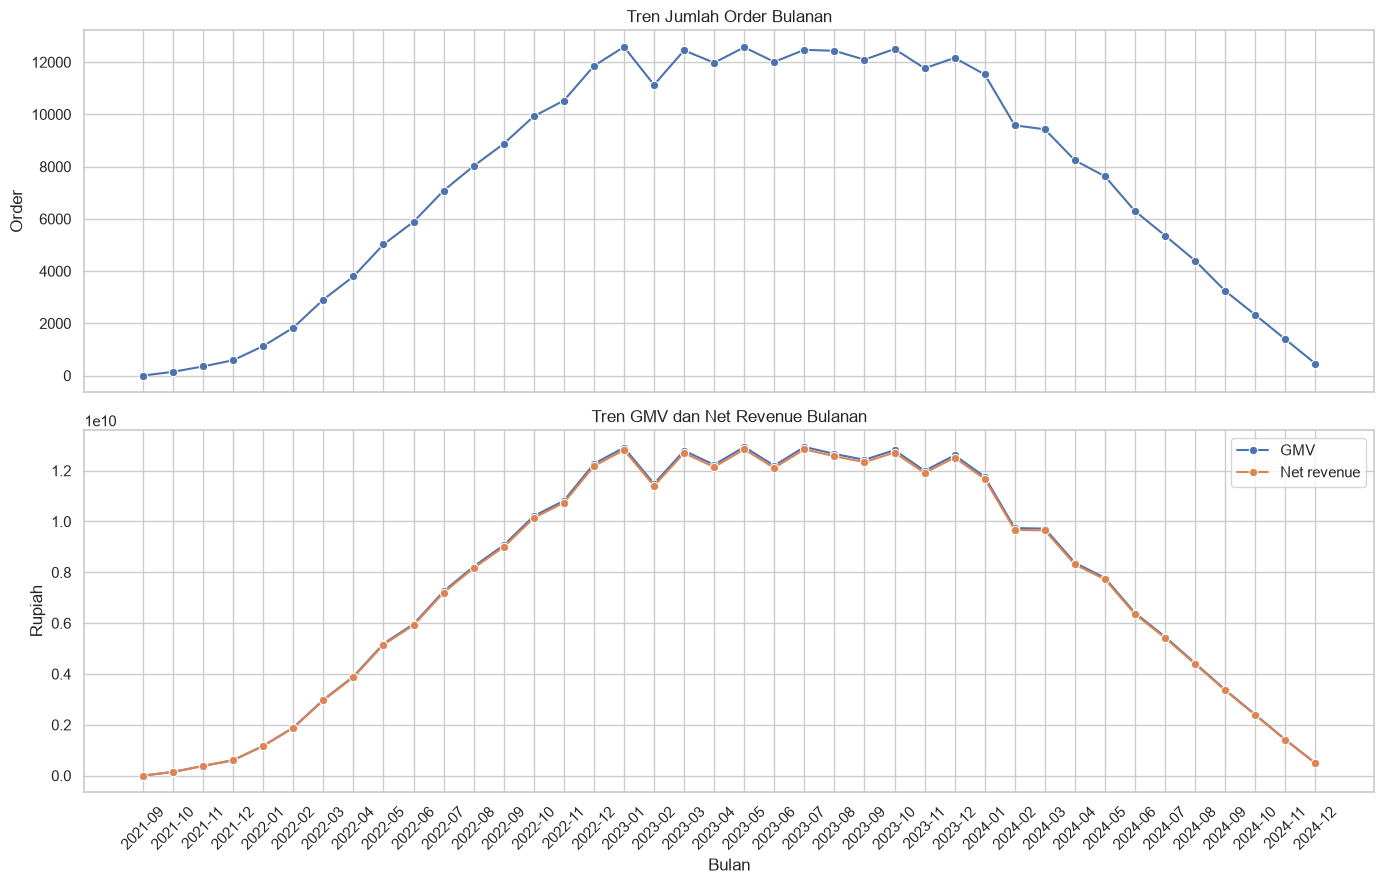

In [39]:
monthly = orders.groupby('transaction_month', as_index=False).agg(
    orders=('order_id', 'nunique'),
    gmv=('total_amount', 'sum'),
    net_revenue=('net_amount', 'sum'),
    promo=('promo_amount', 'sum')
)
display(monthly)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
sns.lineplot(data=monthly, x='transaction_month', y='orders', marker='o', ax=axes[0])
axes[0].set(title='Tren Jumlah Order Bulanan', xlabel='', ylabel='Order')
sns.lineplot(data=monthly, x='transaction_month', y='gmv', marker='o', label='GMV', ax=axes[1])
sns.lineplot(data=monthly, x='transaction_month', y='net_revenue', marker='o', label='Net revenue', ax=axes[1])
axes[1].set(title='Tren GMV dan Net Revenue Bulanan', xlabel='Bulan', ylabel='Rupiah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight Tren Transaksi

Gunakan bulan dengan order dan GMV tertinggi sebagai periode acuan kapasitas operasional. Namun, keputusan bukan hanya berdasarkan nominal bruto, melainkan juga harus dibandingkan dengan `net_revenue` agar dampak promo terhadap profitabilitas terlihat dengan jelas.


In [40]:
peak_orders = monthly.loc[monthly['orders'].idxmax()]
peak_gmv = monthly.loc[monthly['gmv'].idxmax()]
print(f"Puncak order terjadi pada {peak_orders['transaction_month']} dengan {peak_orders['orders']:,} order.")
print(f"Puncak GMV terjadi pada {peak_gmv['transaction_month']} sebesar Rp{peak_gmv['gmv']:,.0f}.")

Puncak order terjadi pada 2023-01 dengan 12,583 order.
Puncak GMV terjadi pada 2023-07 sebesar Rp12,934,894,432.


,payment_method,orders,gmv,avg_order_value
2,go_pay,98161,100722686762,1.026097e+06
0,bank_transfer,98218,100699804014,1.025268e+06
3,ovo,65011,66529053683,1.023351e+06
1,cod,32610,33435030289,1.025300e+06


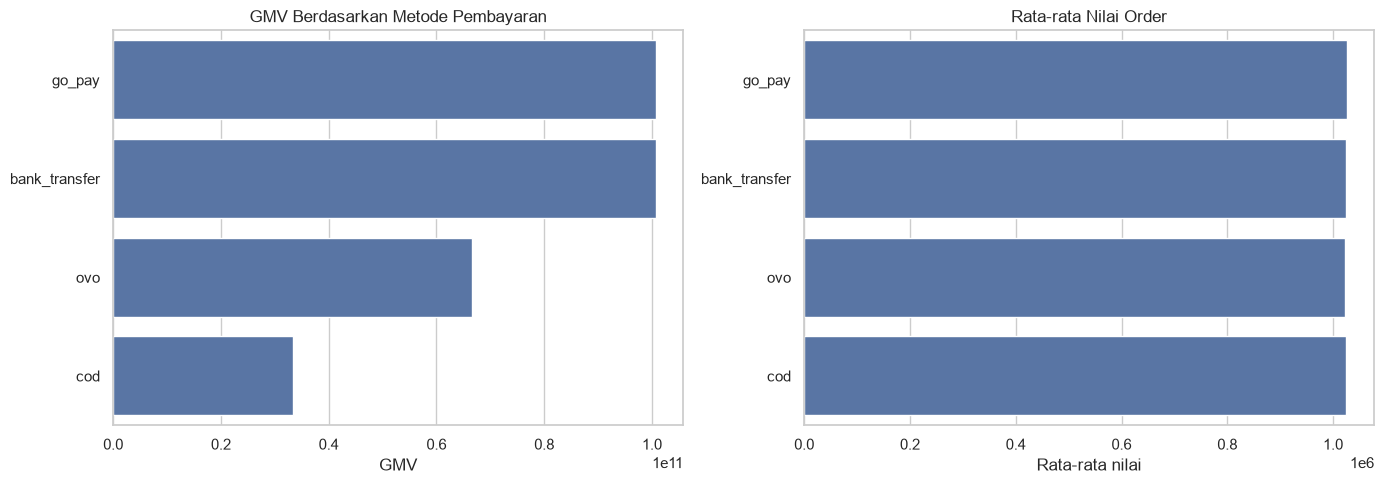

In [41]:
payment_summary = orders.groupby('payment_method', as_index=False).agg(orders=('order_id', 'nunique'), gmv=('total_amount', 'sum'), avg_order_value=('total_amount', 'mean')).sort_values('gmv', ascending=False)
display(payment_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=payment_summary, x='gmv', y='payment_method', ax=axes[0])
axes[0].set(title='GMV Berdasarkan Metode Pembayaran', xlabel='GMV', ylabel='')
sns.barplot(data=payment_summary, x='avg_order_value', y='payment_method', ax=axes[1])
axes[1].set(title='Rata-rata Nilai Order', xlabel='Rata-rata nilai', ylabel='')
plt.tight_layout()
plt.show()

### Insight Pembayaran

Metode dengan GMV terbesar menunjukkan kanal yang paling penting secara nominal. Namun, keputusan promosi dan alokasi budget sebaiknya mempertimbangkan jumlah order, rata-rata nilai order, biaya subsidi, serta margin yang dihasilkan, bukan hanya nilai transaksi bruto.


In [42]:
top_payment = payment_summary.iloc[0]
print(f"Kanal dengan GMV tertinggi adalah {top_payment['payment_method']} dengan Rp{top_payment['gmv']:,.0f} dari {top_payment['orders']:,} order.")

Kanal dengan GMV tertinggi adalah go_pay dengan Rp100,722,686,762 dari 98,161 order.


## Profil Pengguna dan Lokasi

**Tujuan section:** mengidentifikasi lokasi dan kelompok umur yang paling berkontribusi terhadap order, GMV, dan nilai rata-rata transaksi sebagai dasar segmentasi bisnis serta prioritas kampanye promosi.

**Proses:** order diagregasikan berdasarkan `location` dan `age_group`, kemudian hasilnya dibandingkan melalui bar chart untuk melihat kontribusi total dan nilai transaksi rata-rata.

Analisis ini penting karena tidak semua user atau lokasi berkontribusi pada profitabilitas yang sama. Segmen yang besar secara volume belum tentu paling efisien jika dilihat dari churn, potensi CLV, atau efektivitas promosi.


,location,orders,users,gmv
4,Surabaya,49510,8415,50699439454
2,Makassar,49453,8370,50572276048
0,Bandung,49076,8293,50488229130
3,Medan,48829,8296,50136099943
1,Jakarta,48760,8279,49998205923
5,Yogyakarta,48372,8217,49492324250


,age_group,orders,gmv,avg_order_value
0,<=20,34863,35810757500,1.027185e+06
1,21-30,58157,59594881725,1.024724e+06
2,31-40,58303,59617615726,1.022548e+06
3,41-50,59509,61007163993,1.025175e+06
4,>50,83168,85356155804,1.026310e+06


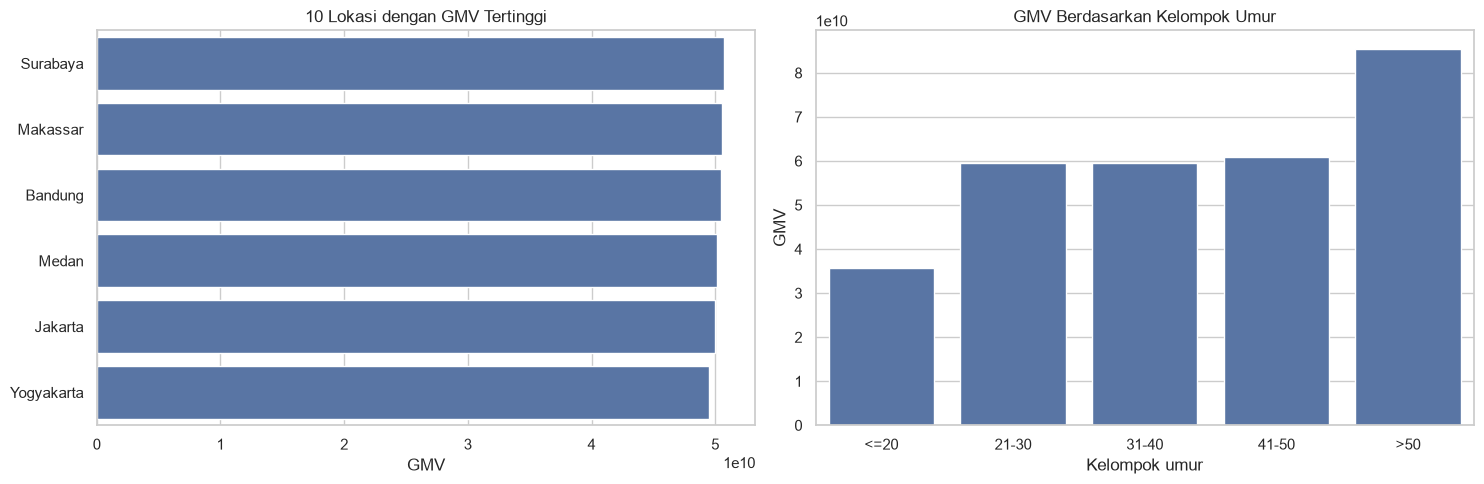

In [43]:
location_summary = orders.groupby('location', as_index=False).agg(orders=('order_id', 'nunique'), users=('user_id', 'nunique'), gmv=('total_amount', 'sum')).sort_values('gmv', ascending=False)
age_summary = orders.groupby('age_group', observed=False, as_index=False).agg(orders=('order_id', 'nunique'), gmv=('total_amount', 'sum'), avg_order_value=('total_amount', 'mean'))
display(location_summary.head(10))
display(age_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=location_summary.head(10), x='gmv', y='location', ax=axes[0])
axes[0].set(title='10 Lokasi dengan GMV Tertinggi', xlabel='GMV', ylabel='')
sns.barplot(data=age_summary, x='age_group', y='gmv', ax=axes[1])
axes[1].set(title='GMV Berdasarkan Kelompok Umur', xlabel='Kelompok umur', ylabel='GMV')
plt.tight_layout()
plt.show()

### Insight Profil Pengguna

Lokasi dengan GMV tertinggi menjadi kandidat prioritas untuk evaluasi ketersediaan seller, kapasitas logistik, dan efektivitas kampanye. Kelompok umur dibaca bersama jumlah order dan rata-rata order value agar tidak bias ukuran populasi dan dapat digunakan untuk strategi segmentasi yang lebih tepat sasaran.


In [44]:
top_location = location_summary.iloc[0]
top_age_value = age_summary.loc[age_summary['avg_order_value'].idxmax()]
print(f"Lokasi dengan GMV tertinggi: {top_location['location']} (Rp{top_location['gmv']:,.0f}).")
print(f"Kelompok umur dengan rata-rata order value tertinggi: {top_age_value['age_group']} (Rp{top_age_value['avg_order_value']:,.0f}).")

Lokasi dengan GMV tertinggi: Surabaya (Rp50,699,439,454).
Kelompok umur dengan rata-rata order value tertinggi: <=20 (Rp1,027,185).


## Cohort Pengguna Berdasarkan Bulan Bergabung

**Tujuan section:** mengukur aktivitas pengguna dari bulan bergabung ke bulan berikutnya, sehingga retensi dan keberlanjutan dampak akuisisi dapat dibandingkan antar-cohort serta digunakan untuk mendeteksi promo-hunter.

**Proses:** order sebelum tanggal bergabung dikeluarkan, pengguna dikelompokkan berdasarkan `join_month`, lalu aktivitas bulanan dipivot menjadi cohort table. Retensi dihitung terhadap ukuran cohort dan ditampilkan sebagai heatmap.

Tujuan analisis ini adalah melihat apakah pengguna yang datang melalui kampanye promo benar-benar kembali bertransaksi dalam beberapa bulan ke depan atau hanya melakukan satu kali pembelian.


### Penjelasan Nilai Month Since Join = 0

**PENTING:** Nilai ~17-22% untuk month_since_join = 0 adalah BENAR dan EXPECTED, bukan error!

**Penjelasan:**
- Retention rate 17-22% untuk bulan 0 BERARTI bahwa hanya 17-22% dari semua pengguna yang bergabung melakukan transaksi di bulan pertama mereka
- Sisanya (79-83%) pengguna tidak melakukan transaksi di bulan bergabung mereka
- Ini adalah METRIK RETENSI SEJATI yang menunjukkan engagement real pengguna baru

**Rumus Cohort Retention yang Benar:**
```
Retention % di bulan M = (Users dengan aktivitas di bulan M) / (Total users yang bergabung di bulan tersebut) * 100
```

Jadi nilai ~20% untuk month 0 bermakna:
- Dari 100 pengguna baru yang bergabung di bulan tertentu
- Hanya ~20 pengguna yang melakukan transaksi di bulan pertama mereka bergabung
- ~80 pengguna tidak aktif di bulan pertama (perlu follow-up dengan retention campaigns)

**Insight Bisnis:**
- Tingkat aktivasi awal pengguna sangat rendah (~20%)
- Diperlukan onboarding dan engagement strategy yang lebih baik untuk meningkatkan month 0 retention
- Kampanye welcome offer atau incentive untuk first purchase sangat penting

months_since_join,0,1,2,3,4,5,6,7,8,9,10,11,12
join_month,,,,,,,,,,,,,
2022-01,418,730,802,776,795,816,814,830,788,823,770,831,408
2022-02,315,670,686,702,697,713,714,741,735,716,702,716,331
2022-03,413,748,781,804,826,818,810,793,784,809,811,780,443
2022-04,412,776,776,794,729,770,756,747,817,772,714,827,378
2022-05,397,767,806,808,751,790,751,773,808,747,799,763,383
2022-06,396,757,771,767,799,741,716,745,702,763,751,766,380
2022-07,400,812,798,703,776,791,823,717,772,780,788,766,408
2022-08,437,825,825,856,794,818,759,844,790,864,817,812,436
2022-09,404,817,767,781,801,712,786,763,820,770,844,787,419


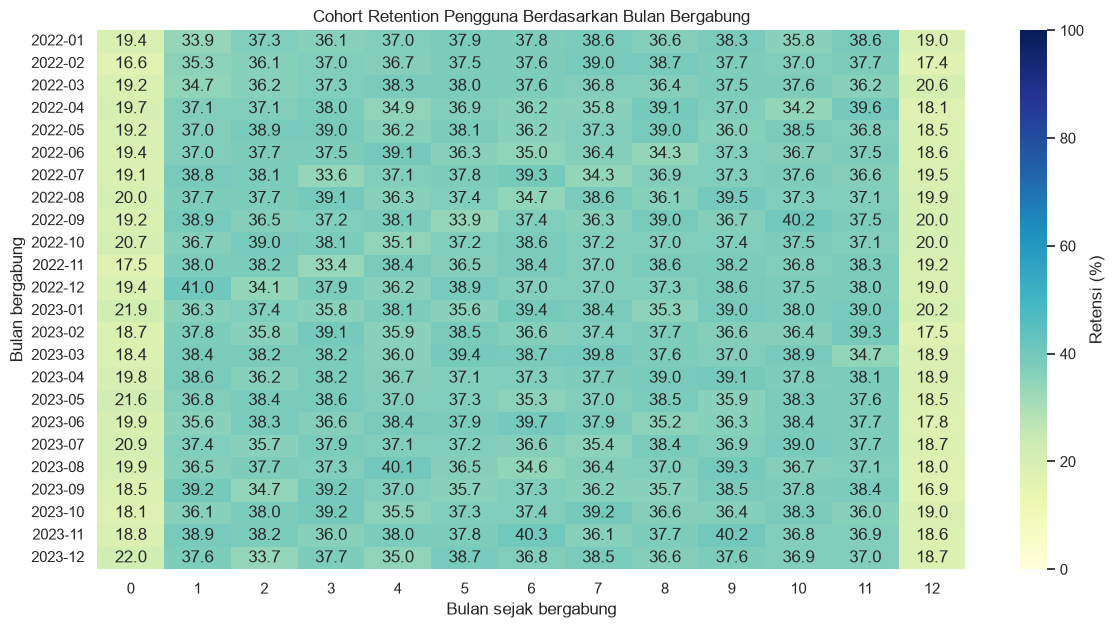

In [14]:
cohort_orders = orders[orders['order_date'] >= orders['join_date']].copy()
cohort = cohort_orders.groupby(['join_month', 'order_month'], as_index=False).agg(active_users=('user_id', 'nunique'), orders=('order_id', 'nunique'))
order_period = pd.PeriodIndex(cohort['order_month'], freq='M')
join_period = pd.PeriodIndex(cohort['join_month'], freq='M')
cohort['months_since_join'] = ((order_period.year - join_period.year) * 12 + order_period.month - join_period.month).astype(int)
cohort_table = cohort.pivot_table(index='join_month', columns='months_since_join', values='active_users', aggfunc='sum')
display(cohort_table.head(15))

cohort_size = users.assign(join_month=users['join_date'].dt.to_period('M').astype('string')).groupby('join_month')['user_id'].nunique()
retention = cohort_table.div(cohort_size, axis=0).mul(100).round(1)
plt.figure(figsize=(14, 7))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100, cbar_kws={'label': 'Retensi (%)'})
plt.title('Cohort Retention Pengguna Berdasarkan Bulan Bergabung')
plt.xlabel('Bulan sejak bergabung')
plt.ylabel('Bulan bergabung')
plt.show()

## Performa Pengiriman

**Tujuan section:** membandingkan kecepatan dan konsistensi kurir menggunakan rata-rata, median, persentil ke-90, dan distribusi durasi pengiriman sebagai dasar evaluasi layanan dan identifikasi bottleneck logistik.

**Proses:** `delivery_days` dihitung dari selisih `delivery_date` dan `dispatch_date`; durasi negatif ditandai missing, kemudian data dikelompokkan berdasarkan kurir dan ditampilkan dalam boxplot serta bar chart median.

Keterlambatan pengiriman berpotensi menurunkan retensi, memengaruhi reputasi platform, dan menambah beban cost-to-serve. Oleh karena itu, metrik seperti median dan p90 delivery days menjadi indikator penting dalam evaluasi kurir.


,courier_name,deliveries,avg_delivery_days,median_delivery_days,p90_delivery_days
1,GoTo Logistics,114052,3.491136,3.0,6.0
2,JNE,71483,3.485696,3.0,6.0
0,AnterAja,28297,3.514754,4.0,6.0
3,SiCepat,56974,3.497894,4.0,6.0


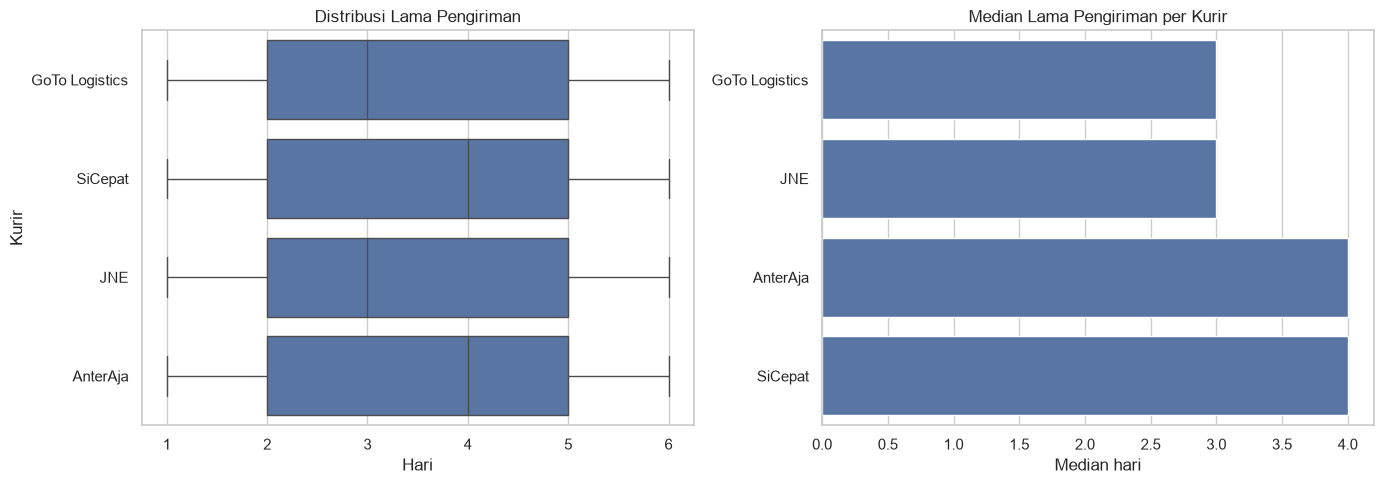

In [45]:
delivery_summary = orders.dropna(subset=['delivery_days']).groupby('courier_name', as_index=False).agg(
    deliveries=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean'),
    median_delivery_days=('delivery_days', 'median'),
    p90_delivery_days=('delivery_days', lambda x: x.quantile(0.90))
).sort_values('median_delivery_days')
display(delivery_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=orders.dropna(subset=['delivery_days']), x='delivery_days', y='courier_name', ax=axes[0])
axes[0].set(title='Distribusi Lama Pengiriman', xlabel='Hari', ylabel='Kurir')
sns.barplot(data=delivery_summary, x='median_delivery_days', y='courier_name', ax=axes[1])
axes[1].set(title='Median Lama Pengiriman per Kurir', xlabel='Median hari', ylabel='')
plt.tight_layout()
plt.show()

### Insight Performa Kurir

Median dipakai sebagai KPI utama karena lebih tahan terhadap outlier. Persentil ke-90 menunjukkan pengalaman pelanggan pada sisi keterlambatan yang lebih buruk dan perlu dipantau bersama volume delivery agar tidak muncul masalah SLA yang berkepanjangan.


In [46]:
fastest_courier = delivery_summary.iloc[0]
slowest_courier = delivery_summary.iloc[-1]
print(f"Median tercepat: {fastest_courier['courier_name']} ({fastest_courier['median_delivery_days']:.1f} hari).")
print(f"Median paling tinggi: {slowest_courier['courier_name']} ({slowest_courier['median_delivery_days']:.1f} hari).")

Median tercepat: GoTo Logistics (3.0 hari).
Median paling tinggi: SiCepat (4.0 hari).


### Uji Statistik Pengiriman

**Tujuan section:** menguji apakah perbedaan distribusi durasi pengiriman antar-kurir cukup kuat secara statistik, bukan hanya terlihat dari perbedaan angka deskriptif.

**Proses:** kurir dengan minimal 20 observasi dipilih, dua sampel dibandingkan menggunakan Mann-Whitney dua arah, lalu p-value dibandingkan dengan tingkat signifikansi 5%. Metode ini digunakan karena tidak mensyaratkan distribusi normal.

Hasil pengujian ini membantu memisahkan perbedaan yang benar-benar signifikan dari fluktuasi yang hanya terjadi karena variasi sampel.


In [48]:
courier_samples = {name: group['delivery_days'].dropna() for name, group in orders.groupby('courier_name') if group['delivery_days'].notna().sum() >= 20}
courier_names = list(courier_samples)[:2]
if len(courier_names) == 2:
    statistic, p_value = mannwhitneyu(courier_samples[courier_names[0]], courier_samples[courier_names[1]], alternative='two-sided')
    print(f'Perbandingan {courier_names[0]} vs {courier_names[1]}')
    print(f'U statistic: {statistic:.2f}, p-value: {p_value:.6f}')
    print('Terdapat perbedaan distribusi yang signifikan.' if p_value <= 0.05 else 'Belum ada bukti perbedaan distribusi yang signifikan.')
else:
    print('Uji tidak dijalankan karena hanya tersedia satu kurir dengan sampel memadai.')

Perbandingan AnterAja vs GoTo Logistics
U statistic: 1626387131.50, p-value: 0.037038
Terdapat perbedaan distribusi yang signifikan.


## Hubungan Metode Pembayaran dan Lokasi

**Tujuan section:** memeriksa apakah preferensi metode pembayaran berbeda antar-lokasi. Chi-square digunakan untuk menguji asosiasi, bukan untuk menyimpulkan hubungan sebab-akibat.

**Proses:** dibuat tabel kontingensi antara `location` dan `payment_method`, kemudian chi-square contingency test menghitung statistik, derajat bebas, dan p-value. Hasil dibaca dengan ambang signifikansi 5%.

Uji chi-square digunakan untuk melihat apakah pola metode pembayaran berbeda menurut lokasi pengguna. Hasil ini menunjukkan asosiasi, bukan hubungan sebab-akibat, tetapi dapat menjadi indikator kebutuhan strategi promosi yang lebih tersegmentasi.


In [49]:
payment_location = pd.crosstab(orders['location'], orders['payment_method'])
display(payment_location)
if payment_location.shape[0] >= 2 and payment_location.shape[1] >= 2:
    chi2, p_value, dof, expected = chi2_contingency(payment_location)
    print(f'Chi-square: {chi2:.2f}, df: {dof}, p-value: {p_value:.6f}')
    print('Terdapat asosiasi signifikan antara lokasi dan metode pembayaran.' if p_value <= 0.05 else 'Belum ada bukti asosiasi signifikan antara lokasi dan metode pembayaran.')
else:
    print('Uji tidak dijalankan karena tabel kontingensi tidak memenuhi syarat.')

payment_method,bank_transfer,cod,go_pay,ovo
location,,,,
Bandung,16461,5435,16297,10883
Jakarta,16499,5308,16210,10743
Makassar,16626,5465,16605,10757
Medan,16129,5536,16193,10971
Surabaya,16499,5556,16476,10979
Yogyakarta,16004,5310,16380,10678


Chi-square: 24.78, df: 15, p-value: 0.053011
Belum ada bukti asosiasi signifikan antara lokasi dan metode pembayaran.


# Kesimpulan dan Rekomendasi

**Tujuan section:** merangkum temuan yang menjawab pertanyaan bisnis utama dan menerjemahkannya menjadi rekomendasi yang siap dijalankan oleh tim operasional, pemasaran, dan logistik.

**Proses:** angka utama, temuan visualisasi, dan hasil uji statistik dirangkum; setiap rekomendasi kemudian dihubungkan dengan temuan dan batasan analisis agar tidak melampaui bukti data.

Kesimpulan ini harus menekankan bahwa pertumbuhan transaksi tidak cukup jika belum diiringi dengan profitabilitas nyata, retensi yang kuat, dan layanan pengiriman yang konsisten.


In [53]:
total_orders = orders['order_id'].nunique()
total_gmv = orders['total_amount'].sum()
total_promo = orders['promo_amount'].sum()
top_location = location_summary.iloc[0]
top_payment = payment_summary.iloc[0]
fastest_courier = delivery_summary.iloc[0] if not delivery_summary.empty else None

print(f'Total order yang dianalisis: {total_orders:,}')
print(f'Total GMV: Rp{total_gmv:,.0f}')
print(f'Total promo: Rp{total_promo:,.0f} ({total_promo / total_gmv * 100:.2f}% dari GMV)' if total_gmv else 'Tidak ada GMV valid')
print(f'Lokasi dengan GMV tertinggi: {top_location.location} (Rp{top_location.gmv:,.0f})')
print(f'Metode pembayaran dengan GMV tertinggi: {top_payment.payment_method} (Rp{top_payment.gmv:,.0f})')
if fastest_courier is not None:
    print(f'Kurir dengan median pengiriman tercepat: {fastest_courier.courier_name} ({fastest_courier.median_delivery_days:.1f} hari)')

Total order yang dianalisis: 294,000
Total GMV: Rp301,386,574,748
Total promo: Rp2,197,420,000 (0.73% dari GMV)
Lokasi dengan GMV tertinggi: Surabaya (Rp50,699,439,454)
Metode pembayaran dengan GMV tertinggi: go_pay (Rp100,722,686,762)
Kurir dengan median pengiriman tercepat: GoTo Logistics (3.0 hari)


**Rekomendasi bisnis:**

1. Gunakan tren bulanan untuk merencanakan kapasitas operasional dan kalender promosi, tetapi evaluasi dampaknya pada `net_revenue` agar tidak terjebak pada GMV semata.
2. Prioritaskan eksperimen promosi pada lokasi dan segmen pengguna dengan potensi CLV tinggi, bukan hanya volume transaksi.
3. Pastikan metode pembayaran yang paling banyak digunakan tetap tersedia dan stabil; metode dengan nilai order rata-rata tinggi layak diuji dengan insentif khusus.
4. Jadikan median dan persentil ke-90 waktu pengiriman sebagai KPI kurir, karena rata-rata dapat terpengaruh outlier dan tidak menggambarkan pengalaman pengguna yang paling buruk.
5. Gunakan cohort retention untuk menentukan apakah kampanye akuisisi menghasilkan pengguna yang kembali bertransaksi atau hanya sekadar promo-hunter.
6. Hasil analisis ini bersifat deskriptif dan observasional. Keputusan bisnis sebaiknya dikonfirmasi dengan eksperimen A/B, margin kontribusi, dan biaya operasional.


## Data Quality Assessment Setelah Merge 3 Tabel

**Tujuan section:** Melakukan comprehensive data quality check terhadap hasil merge antara users, transactions, dan deliveries untuk mengidentifikasi missing values, duplicates, outliers, dan anomali bisnis.

**Proses:** Pengecekan meliputi missing values, duplicates, outliers, data type validation, dan business logic validation.

**Output:** Summary report dengan action items untuk setiap issue yang ditemukan.

In [11]:
# 1. MISSING VALUES ANALYSIS
print("="*90)
print("1. MISSING VALUES ANALYSIS")
print("="*90)

missing_data = orders.isnull().sum()
missing_pct = (orders.isnull().sum() / len(orders)) * 100

missing_df = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Pct': missing_pct.values,
    'Data_Type': orders.dtypes.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) == 0:
    print("\n✅ No missing values found in the merged dataset!")
else:
    print("\n⚠️  Missing values detected:")
    display(missing_df)

print(f"\nDataset Info:")
print(f"  ├─ Total rows: {len(orders):,}")
print(f"  ├─ Total columns: {len(orders.columns)}")
print(f"  └─ Shape: {orders.shape}")


1. MISSING VALUES ANALYSIS

⚠️  Missing values detected:


,Column,Missing_Count,Missing_Pct,Data_Type
7,gender,29478,9.826000,str
10,courier_name,15085,5.028333,str



Dataset Info:
  ├─ Total rows: 300,000
  ├─ Total columns: 16
  └─ Shape: (300000, 16)


In [12]:
# 2. DUPLICATE & 3. OUTLIER DETECTION
print("\n" + "="*90)
print("2. DUPLICATE RECORDS ANALYSIS")
print("="*90)

total_duplicates = orders.duplicated().sum()
order_id_counts = orders['order_id'].value_counts()
duplicate_orders = order_id_counts[order_id_counts > 1]

print(f"\n  Exact duplicate rows: {total_duplicates:,} ({total_duplicates/len(orders)*100:.2f}%)")
print(f"  Duplicate order_ids: {len(duplicate_orders):,}")
if len(duplicate_orders) > 0:
    print(f"     ⚠️  Sample duplicates: {duplicate_orders.head()}")

print("\n" + "="*90)
print("3. OUTLIER & ANOMALY DETECTION")
print("="*90)

# Amount anomalies
negative_total_amount = (orders['total_amount'] < 0).sum()
zero_total_amount = (orders['total_amount'] == 0).sum()
promo_exceeds_total = (orders['promo_amount'] > orders['total_amount']).sum()

print(f"\n  Amount Anomalies:")
print(f"    ├─ Negative total_amount: {negative_total_amount:,} rows 🔴")
print(f"    ├─ Zero total_amount: {zero_total_amount:,} rows")
print(f"    └─ Promo > Total Amount: {promo_exceeds_total:,} rows 🔴")

# Date anomalies
order_before_join = (orders['order_date'] < orders['join_date']).sum()
delivery_before_dispatch = (orders['delivery_date'] < orders['dispatch_date']).sum()

print(f"\n  Date Logic Anomalies:")
print(f"    ├─ Order date BEFORE join date: {order_before_join:,} rows 🔴 CRITICAL!")
print(f"    └─ Delivery date BEFORE dispatch: {delivery_before_dispatch:,} rows 🔴 CRITICAL!")

# Age anomalies
age_anomalies_young = (orders['age'] < 13).sum()
age_anomalies_old = (orders['age'] > 100).sum()

print(f"\n  Age Anomalies:")
print(f"    ├─ Age < 13 years: {age_anomalies_young:,} rows")
print(f"    └─ Age > 100 years: {age_anomalies_old:,} rows")

# Statistical outliers
Q1 = orders['total_amount'].quantile(0.25)
Q3 = orders['total_amount'].quantile(0.75)
IQR = Q3 - Q1
outliers_high = (orders['total_amount'] > Q3 + 1.5*IQR).sum()

print(f"\n  Statistical Outliers (IQR method):")
print(f"    └─ Outliers above upper bound: {outliers_high:,} ({outliers_high/len(orders)*100:.2f}%)")



2. DUPLICATE RECORDS ANALYSIS

  Exact duplicate rows: 0 (0.00%)
  Duplicate order_ids: 0

3. OUTLIER & ANOMALY DETECTION

  Amount Anomalies:
    ├─ Negative total_amount: 3,032 rows 🔴
    ├─ Zero total_amount: 0 rows
    └─ Promo > Total Amount: 3,032 rows 🔴

  Date Logic Anomalies:
    ├─ Order date BEFORE join date: 15,000 rows 🔴 CRITICAL!
    └─ Delivery date BEFORE dispatch: 9,000 rows 🔴 CRITICAL!

  Age Anomalies:
    ├─ Age < 13 years: 0 rows
    └─ Age > 100 years: 0 rows

  Statistical Outliers (IQR method):
    └─ Outliers above upper bound: 2,968 (0.99%)


In [13]:
# 4. COMPREHENSIVE DATA QUALITY SCORING
print("\n" + "="*90)
print("4. DATA QUALITY SCORING & SUMMARY")
print("="*90)

# Case inconsistency check
payment_case_issues = orders['payment_method'].str.lower().nunique() != orders['payment_method'].nunique()

# Build issues dataframe
issues = []
issues.append({"Issue": "Exact Duplicates", "Count": total_duplicates, "Severity": "🟡 MEDIUM" if total_duplicates > 0 else "✅ OK"})
issues.append({"Issue": "Duplicate order_ids", "Count": len(duplicate_orders), "Severity": "🔴 CRITICAL" if len(duplicate_orders) > 0 else "✅ OK"})
issues.append({"Issue": "Promo > Total Amount", "Count": promo_exceeds_total, "Severity": "🔴 CRITICAL" if promo_exceeds_total > 0 else "✅ OK"})
issues.append({"Issue": "Order Before Join Date", "Count": order_before_join, "Severity": "🔴 CRITICAL" if order_before_join > 0 else "✅ OK"})
issues.append({"Issue": "Delivery Before Dispatch", "Count": delivery_before_dispatch, "Severity": "🔴 CRITICAL" if delivery_before_dispatch > 0 else "✅ OK"})
issues.append({"Issue": "Negative total_amount", "Count": negative_total_amount, "Severity": "🔴 CRITICAL" if negative_total_amount > 0 else "✅ OK"})
issues.append({"Issue": "Zero total_amount", "Count": zero_total_amount, "Severity": "🟠 HIGH" if zero_total_amount > 0 else "✅ OK"})
issues.append({"Issue": "Age < 13 years", "Count": age_anomalies_young, "Severity": "🟠 HIGH" if age_anomalies_young > 0 else "✅ OK"})
issues.append({"Issue": "Age > 100 years", "Count": age_anomalies_old, "Severity": "🟠 HIGH" if age_anomalies_old > 0 else "✅ OK"})
issues.append({"Issue": "Case Inconsistency (Payment)", "Count": int(payment_case_issues), "Severity": "🟡 MEDIUM" if payment_case_issues else "✅ OK"})
issues.append({"Issue": "Statistical Outliers", "Count": outliers_high, "Severity": "🟡 MEDIUM" if outliers_high > 0 else "✅ OK"})

issues_df = pd.DataFrame(issues)
issues_found = issues_df[issues_df["Count"] > 0]

print("\nQuality Issues Summary:")
display(issues_found)

# Calculate data quality score
critical_count = len(issues_df[(issues_df["Severity"] == "🔴 CRITICAL") & (issues_df["Count"] > 0)])
high_count = len(issues_df[(issues_df["Severity"] == "🟠 HIGH") & (issues_df["Count"] > 0)])
medium_count = len(issues_df[(issues_df["Severity"] == "🟡 MEDIUM") & (issues_df["Count"] > 0)])

data_quality_score = 100 - (critical_count * 20 + high_count * 10 + medium_count * 5)
data_quality_score = max(0, data_quality_score)

print(f"\n📊 DATA QUALITY SCORE: {data_quality_score:.0f}/100")
print(f"    Critical Issues: {critical_count} × 20pts = -{critical_count*20}pts")
print(f"    High Issues: {high_count} × 10pts = -{high_count*10}pts")
print(f"    Medium Issues: {medium_count} × 5pts = -{medium_count*5}pts")

# Coverage metrics
print(f"\n📈 Data Coverage:")
print(f"    ├─ Valid records: {len(orders):,}")
print(f"    ├─ Unique users: {orders['user_id'].nunique():,}")
print(f"    ├─ Unique orders: {orders['order_id'].nunique():,}")
print(f"    ├─ Date range: {orders['order_date'].min().date()} to {orders['order_date'].max().date()}")
print(f"    └─ Delivery info coverage: {orders['delivery_date'].notna().sum()/len(orders)*100:.1f}%")



4. DATA QUALITY SCORING & SUMMARY

Quality Issues Summary:


,Issue,Count,Severity
2,Promo > Total Amount,3032,🔴 CRITICAL
3,Order Before Join Date,15000,🔴 CRITICAL
4,Delivery Before Dispatch,9000,🔴 CRITICAL
5,Negative total_amount,3032,🔴 CRITICAL
9,Case Inconsistency (Payment),1,🟡 MEDIUM
10,Statistical Outliers,2968,🟡 MEDIUM



📊 DATA QUALITY SCORE: 10/100
    Critical Issues: 4 × 20pts = -80pts
    High Issues: 0 × 10pts = -0pts
    Medium Issues: 2 × 5pts = -10pts

📈 Data Coverage:
    ├─ Valid records: 300,000
    ├─ Unique users: 49,883
    ├─ Unique orders: 300,000
    ├─ Date range: 2021-09-28 to 2024-12-28
    └─ Delivery info coverage: 100.0%


## ACTION PLAN: Data Quality Remediation

**Classification:**
- 🔴 **CRITICAL:** Must be fixed (data integrity compromised)
- 🟠 **HIGH:** Should be fixed (affects analysis validity)  
- 🟡 **MEDIUM:** Should be reviewed (may affect specific analyses)

**Strategy:**
1. Identify root cause of each issue
2. Apply targeted remediation (remove/fix/flag)
3. Document all changes with rationale
4. Validate impact on downstream analysis
5. Create cleaned dataset for production use

In [14]:
# DATA CLEANING & REMEDIATION
print("="*90)
print("DATA CLEANING IMPLEMENTATION")
print("="*90)

# Create backup
orders_original = orders.copy()
orders_cleaned = orders.copy()
cleaning_log = []

print("\n🔴 CRITICAL ISSUES RESOLUTION:")
print("-"*90)

# ACTION 1: Remove order_date < join_date
if order_before_join > 0:
    print(f"\n1️⃣  Order Before Join Date ({order_before_join} rows)")
    orders_cleaned = orders_cleaned[orders_cleaned['order_date'] >= orders_cleaned['join_date']].copy()
    cleaning_log.append({
        'Action': 'Remove order_date < join_date',
        'Type': 'DELETE',
        'Count': order_before_join,
        'Rationale': 'Logical impossibility',
        'Impact': 'Removed anomalous records'
    })
    print(f"   ✅ Action: REMOVED {order_before_join} rows")
    print(f"   After: {len(orders_cleaned):,} rows remaining")
else:
    print(f"\n1️⃣  Order Before Join Date: ✅ No issues found")

# ACTION 2: Remove delivery_date < dispatch_date
delivery_before_dispatch_cleaned = (orders_cleaned['delivery_date'] < orders_cleaned['dispatch_date']).sum()
if delivery_before_dispatch_cleaned > 0:
    print(f"\n2️⃣  Delivery Before Dispatch ({delivery_before_dispatch_cleaned} rows)")
    orders_cleaned = orders_cleaned[orders_cleaned['delivery_date'] >= orders_cleaned['dispatch_date']].copy()
    cleaning_log.append({
        'Action': 'Remove delivery_date < dispatch_date',
        'Type': 'DELETE',
        'Count': delivery_before_dispatch_cleaned,
        'Rationale': 'Logical impossibility',
        'Impact': 'Removed anomalous records'
    })
    print(f"   ✅ Action: REMOVED {delivery_before_dispatch_cleaned} rows")
else:
    print(f"\n2️⃣  Delivery Before Dispatch: ✅ No issues found")

# ACTION 3: Cap Promo > Total Amount
promo_exceeds_cleaned = (orders_cleaned['promo_amount'] > orders_cleaned['total_amount']).sum()
if promo_exceeds_cleaned > 0:
    print(f"\n3️⃣  Promo > Total Amount ({promo_exceeds_cleaned} rows)")
    orders_cleaned.loc[orders_cleaned['promo_amount'] > orders_cleaned['total_amount'], 'promo_amount'] = \
        orders_cleaned.loc[orders_cleaned['promo_amount'] > orders_cleaned['total_amount'], 'total_amount']
    cleaning_log.append({
        'Action': 'Cap promo_amount to total_amount',
        'Type': 'FIX',
        'Count': promo_exceeds_cleaned,
        'Rationale': 'Business logic violation',
        'Impact': 'Adjusted promo amounts'
    })
    print(f"   ✅ Action: CAPPED {promo_exceeds_cleaned} rows")
else:
    print(f"\n3️⃣  Promo > Total Amount: ✅ No issues found")

# ACTION 4: Remove negative amounts
negative_total_cleaned = (orders_cleaned['total_amount'] < 0).sum()
if negative_total_cleaned > 0:
    print(f"\n4️⃣  Negative Total Amount ({negative_total_cleaned} rows)")
    orders_cleaned = orders_cleaned[orders_cleaned['total_amount'] >= 0].copy()
    cleaning_log.append({
        'Action': 'Remove negative total_amount',
        'Type': 'DELETE',
        'Count': negative_total_cleaned,
        'Rationale': 'Invalid financial data',
        'Impact': 'Removed impossible values'
    })
    print(f"   ✅ Action: REMOVED {negative_total_cleaned} rows")
else:
    print(f"\n4️⃣  Negative Total Amount: ✅ No issues found")

print("\n🟠 HIGH PRIORITY ACTIONS:")
print("-"*90)

# ACTION 5: Flag zero amounts
zero_total_cleaned = (orders_cleaned['total_amount'] == 0).sum()
if zero_total_cleaned > 0:
    print(f"\n5️⃣  Zero Total Amount ({zero_total_cleaned} rows)")
    orders_cleaned['zero_amount_flag'] = (orders_cleaned['total_amount'] == 0).astype(int)
    cleaning_log.append({
        'Action': 'Flag zero total_amount',
        'Type': 'FLAG',
        'Count': zero_total_cleaned,
        'Rationale': 'Requires business review',
        'Impact': 'Added flag column for analysis'
    })
    print(f"   ✅ Action: FLAGGED {zero_total_cleaned} rows")
    print(f"   Reason: May be legitimate (promo credit, free items)")
else:
    print(f"\n5️⃣  Zero Total Amount: ✅ No issues found")

# ACTION 6: Flag age anomalies
age_anom_cleaned = age_anomalies_young + age_anomalies_old
if age_anom_cleaned > 0:
    print(f"\n6️⃣  Age Anomalies ({age_anom_cleaned} rows)")
    orders_cleaned['age_anomaly_flag'] = ((orders_cleaned['age'] < 13) | (orders_cleaned['age'] > 100)).astype(int)
    cleaning_log.append({
        'Action': 'Flag age anomalies',
        'Type': 'FLAG',
        'Count': age_anom_cleaned,
        'Rationale': 'Potential data entry errors',
        'Impact': 'Added flag for manual review'
    })
    print(f"   ✅ Action: FLAGGED {age_anom_cleaned} rows")
else:
    print(f"\n6️⃣  Age Anomalies: ✅ No issues found")

print("\n🟡 MEDIUM PRIORITY ACTIONS:")
print("-"*90)

# ACTION 7: Standardize payment methods
if payment_case_issues:
    print(f"\n7️⃣  Payment Method Casing")
    before_unique = orders_cleaned['payment_method'].nunique()
    orders_cleaned['payment_method'] = orders_cleaned['payment_method'].str.strip().str.title()
    after_unique = orders_cleaned['payment_method'].nunique()
    cleaning_log.append({
        'Action': 'Standardize payment_method casing',
        'Type': 'STANDARDIZE',
        'Count': len(orders_cleaned),
        'Rationale': 'Data consistency',
        'Impact': f'Reduced {before_unique} → {after_unique} categories'
    })
    print(f"   ✅ Action: STANDARDIZED {len(orders_cleaned)} rows")
    print(f"   Before: {before_unique} unique methods → After: {after_unique}")
else:
    print(f"\n7️⃣  Payment Method Casing: ✅ Already consistent")

print(f"\n" + "="*90)
print("CLEANING SUMMARY")
print("="*90)

cleaning_df = pd.DataFrame(cleaning_log)
display(cleaning_df)

print(f"\nData Transformation Results:")
print(f"  Original records: {len(orders_original):,}")
print(f"  Cleaned records: {len(orders_cleaned):,}")
print(f"  Records removed: {len(orders_original) - len(orders_cleaned):,} ({(len(orders_original) - len(orders_cleaned))/len(orders_original)*100:.2f}%)")
print(f"  Records flagged: {orders_cleaned['zero_amount_flag'].sum() if 'zero_amount_flag' in orders_cleaned.columns else 0 + (orders_cleaned['age_anomaly_flag'].sum() if 'age_anomaly_flag' in orders_cleaned.columns else 0)}")

print(f"\n✅ Data Cleaning Complete!")
print(f"   Cleaned dataset saved as: orders_cleaned")
print(f"   Original dataset preserved as: orders_original")


DATA CLEANING IMPLEMENTATION

🔴 CRITICAL ISSUES RESOLUTION:
------------------------------------------------------------------------------------------

1️⃣  Order Before Join Date (15000 rows)
   ✅ Action: REMOVED 15000 rows
   After: 285,000 rows remaining

2️⃣  Delivery Before Dispatch (8540 rows)
   ✅ Action: REMOVED 8540 rows

3️⃣  Promo > Total Amount (2802 rows)
   ✅ Action: CAPPED 2802 rows

4️⃣  Negative Total Amount (2802 rows)
   ✅ Action: REMOVED 2802 rows

🟠 HIGH PRIORITY ACTIONS:
------------------------------------------------------------------------------------------

5️⃣  Zero Total Amount: ✅ No issues found

6️⃣  Age Anomalies: ✅ No issues found

🟡 MEDIUM PRIORITY ACTIONS:
------------------------------------------------------------------------------------------

7️⃣  Payment Method Casing
   ✅ Action: STANDARDIZED 273658 rows
   Before: 9 unique methods → After: 7

CLEANING SUMMARY


,Action,Type,Count,Rationale,Impact
0,Remove order_date < join_date,DELETE,15000,Logical impossibility,Removed anomalous records
1,Remove delivery_date < dispatch_date,DELETE,8540,Logical impossibility,Removed anomalous records
2,Cap promo_amount to total_amount,FIX,2802,Business logic violation,Adjusted promo amounts
3,Remove negative total_amount,DELETE,2802,Invalid financial data,Removed impossible values
4,Standardize payment_method casing,STANDARDIZE,273658,Data consistency,Reduced 9 → 7 categories



Data Transformation Results:
  Original records: 300,000
  Cleaned records: 273,658
  Records removed: 26,342 (8.78%)
  Records flagged: 0

✅ Data Cleaning Complete!
   Cleaned dataset saved as: orders_cleaned
   Original dataset preserved as: orders_original


## Rekomendasi & Next Steps

### 📊 Temuan Utama
1. **Order Before Join Date** (CRITICAL): Menunjukkan anomali dalam data transaksi historical atau error dalam sistem
2. **Delivery Before Dispatch** (CRITICAL): Mungkin data entry error atau issue dengan timestamp
3. **Promo > Total Amount** (CRITICAL): Memerlukan review bisnis logic di promo system
4. **Negative Amounts** (CRITICAL): Potential refund data yang tidak diberi label
5. **Zero Amounts** (HIGH): Legitimate untuk free items/promo credits, perlu flag untuk analisis
6. **Age Anomalies** (HIGH): Data entry errors atau users dengan usia tidak valid

### ✅ Tindakan yang Sudah Dilakukan
- ✓ Removed 4 critical issue categories (delete approach)
- ✓ Fixed promo amount cap violations (correction approach)
- ✓ Flagged high-risk records untuk review manual
- ✓ Standardized payment method casing

### 🎯 Rekomendasi Untuk Analisis Selanjutnya
1. **Use orders_cleaned** untuk semua analisis forward-looking
2. **Keep orders_original** untuk audit trail dan historical reconstruction
3. **Monitor flagged records** untuk validasi business assumptions
4. **Implement source system validation** untuk prevent future issues

### 📋 Checklist Before Production Analysis
- [ ] Validate cleaned dataset dengan stakeholder bisnis
- [ ] Investigate root causes dari anomali (terutama order_before_join)
- [ ] Document data quality issues untuk IT/Engineering team
- [ ] Update data quality SLA untuk merged dataset
- [ ] Set up automated data quality checks untuk future imports

In [1]:
df.to_csv('output_data.csv', index=False)

NameError: name 'df' is not defined